# <h1 style="text-align: center;">4. PREDICTIVE — Questions and Answers</h1>

## About this notebook
**Data:** `Team05_PyCraft_Cleaned_data/wide_merged_table.csv`: 2,008 heart-failure admissions to Zigong Fourth People's Hospital (Sichuan, China), one row per patient, from the PhysioNet dataset *Hospitalized patients with heart failure: integrating electronic healthcare records and external outcome data* (v1.3). According to the dataset description:
* vital signs, NYHA class, Killip class and the Glasgow Coma Scale were measured **on the day of admission**;
* medicines were given **during** the stay (no times recorded);
* deaths and readmissions were collected at compulsory follow-ups at **28 days, 3 months and 6 months**;
* the data was collected **to develop a model predicting readmission** of discharged patients;
* it comes from a **single hospital**, so models may not transfer directly to other hospitals.

**How to run it:** You need pandas, numpy, matplotlib and scikit-learn (`pip install scikit-learn` if it is missing).

**Each question has:** Reasoning → Hypothesis → Markers used → Model used for prediction → Why this model was chosen → code (model + chart) → How to read the chart → The predictive analysis and model accuracy → Key Insights.

## Why do we need a predictive model?
Doctors already see every test result. So why build a model?
1. **No single test is enough.** The best single marker predicts 6-month death with an AUC of only about 0.76, and most are around 0.65 (question 2). Risk comes from several body systems at once (heart, kidneys, oxygen, consciousness), and a model adds these signals up consistently for every patient.
2. **Resources are limited.** Follow-up visits, intensive-care beds and senior reviews cannot be given to everyone. A model ranks patients so the riskiest are seen first (questions 11, 12, 26, 27).
3. **Fair comparisons need risk adjustment.** Departments treating sicker patients will have more deaths; a model estimates how many deaths to *expect* (question 37).
4. **Some information is missing.** Two-thirds of patients never had an echo scan; a model can estimate who is most likely to have a weak heart pump and should be scanned first (question 34).

## How the models were chosen
* **Main model: logistic regression.** It gives a probability for each patient, shows how every marker pushes the risk up or down (odds ratios), and is well understood in medicine. With only 57 deaths, a simple model with strong shrinkage (regularisation) avoids memorising noise.
* **Second opinions: random forest and gradient boosting.** These flexible tree-based models can find curves and interactions. They were compared on the same patients (questions 7, 18). They did **not** beat logistic regression, so they are used only to confirm which markers matter (questions 9, 20, 42).
* **Other model types where the question needs them:** regression for length of stay (question 29), Kaplan–Meier curves for *when* readmissions happen (question 28), k-means clustering to discover patient types (question 36).
* **Fair testing everywhere:** every score comes from patients the model did not see (5-fold cross-validation), plus a test on a later year (question 38). Only information available at the time of the decision is used (question 4).

## Glossary: statistics
| Term | Plain meaning |
|---|---|
| **AUC** (area under the ROC curve) | If we pick one patient with the event and one without, the chance the model gives the first a higher risk. 0.5 = coin toss, 0.6–0.7 modest, 0.7–0.8 fair, 0.8–0.9 good, above 0.9 excellent |
| **ROC curve** | A chart of all possible alert levels: up = share of events caught, across = share of false alarms |
| **95% confidence interval (CI)** | The range the true value very probably lies in. If it does not include 0.5 (for AUC) or 0 (for a difference), the result is statistically significant |
| **p-value** | The chance of seeing a result this strong if the model were really useless (H0 true). Below 0.05 = significant |
| **H0 / H1** | Null hypothesis (no effect, no better than chance) / alternative hypothesis (a real effect) |
| **Cross-validation** | Split the patients into 5 groups; predict each group with a model trained on the other 4. Every prediction is for an "unseen" patient |
| **Overfitting** | A model memorising the training patients' quirks and failing on new patients |
| **Shrinkage (regularisation)** | Pulling a model's weights towards zero so it cannot chase noise; controlled by C (smaller = stronger) |
| **Odds ratio (OR) per SD** | How much the odds of the event multiply for a typical-sized (1 standard deviation) increase in a marker; 1 = no effect |
| **Calibration** | Whether predicted percentages match the real rates |
| **Brier score** | Average squared error of predicted probabilities (0 = perfect; lower is better) |
| **Data leakage** | Accidentally using information recorded after the outcome, which makes a model look better than it is |
| **Bootstrap** | Recalculating a result on many resampled copies of the data to measure its uncertainty |

## Glossary: medical terms (with column names)
| Term (abbreviation) | Plain meaning | Column |
|---|---|---|
| Heart failure (HF) | The heart cannot pump enough blood for the body's needs | whole dataset |
| NYHA class | How much breathlessness limits daily life (2 = on moderate effort, 4 = at rest) | `heart_failure_severity` |
| Killip class | Signs of fluid on the lungs or shock (1 = none, 4 = cardiogenic shock) | `heart_damage_level` |
| Glasgow Coma Scale (GCS) | Level of consciousness, 3 (unresponsive) to 15 (fully alert) | `gcs` |
| B-type natriuretic peptide (BNP) | Hormone released by a stretched, struggling heart | `brain_natriuretic_peptide` (`log_BNP` in models) |
| High-sensitivity troponin | Protein released when heart muscle is damaged | `high_sensitivity_troponin` (`log_troponin`) |
| D-dimer | Marker of clot formation and breakdown | `d_dimer` (`log_d_dimer`) |
| Estimated glomerular filtration rate (eGFR) | How well the kidneys filter blood (higher = better; below 60 = impaired) | `glomerular_filtration_rate` |
| Urea, uric acid | Waste products cleared by the kidneys; rise when kidneys struggle | `urea`, `uric_acid` |
| CO₂ capacity | Bicarbonate: low values mean the blood is too acidic | `CO2_capacity` |
| Left ventricular ejection fraction (LVEF) | % of blood pumped out with each beat, from an echo scan | `heart_pumping_efficiency` |
| HFrEF | Heart failure with reduced ejection fraction: a weak pump (LVEF below 40%) | derived: `weak_pump_HFrEF` |
| Guideline-directed medical therapy (GDMT) | The main proven heart-failure drug types: beta-blocker, ACE inhibitor/ARB, MRA (spironolactone) | derived: `gdmt_count` |
| IV diuretic / IV inotrope | Water medicine / heart-strengthening medicine given into a vein | `iv_diuretic`, `iv_inotrope` |
| Chronic obstructive pulmonary disease (COPD) | Long-term lung disease | `chronic_obstructive_pulmonary_disease` |
| Type II respiratory failure | The lungs cannot clear carbon dioxide | `type2_respiratory_failure` |

## Setup cell (run first)
Loads the wide table, creates the model inputs (for example `age` from `age_category`, BNP on a log scale), defines the groups of markers and the shared tools: the models, fair cross-validated testing, AUC with confidence interval and p-value, and chart helpers.

In [1]:
# ============================================================================
# SETUP CELL: run this ONCE before the question cells below.
# Loads the wide table, prepares the model inputs and defines the shared tools.
# Needs: pandas, numpy, matplotlib, scikit-learn
# ============================================================================
import math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, HistGradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, KFold, cross_val_predict
from sklearn.metrics import roc_auc_score, roc_curve, brier_score_loss, mean_absolute_error, r2_score
from sklearn.inspection import permutation_importance, partial_dependence
from sklearn.cluster import KMeans
warnings.filterwarnings("ignore")
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 20)

hf = pd.read_csv("Team05_PyCraft_Cleaned_data/wide_merged_table.csv")

# ---- Safety check: blank any physically impossible lab value (e.g. potassium 11.1 mmol/L) so the models never learn from it ----
PLAUSIBLE = {"potassium": (1.5, 9.0), "sodium": (100, 180), "CO2_capacity": (3, 60), "albumin": (10, 60), "hemoglobin": (25, 220),
             "urea": (0.5, 80), "uric_acid": (30, 1500), "glomerular_filtration_rate": (1, 300), "temp": (33, 42.5),
             "pulse": (20, 250), "resp": (5, 60), "sbp": (50, 280), "dbp": (20, 180)}
for col, (lo, hi) in PLAUSIBLE.items():
    impossible = hf[col].notna() & ~hf[col].between(lo, hi)
    if impossible.any():
        print(f"Blanked {int(impossible.sum())} impossible {col} value(s): {hf.loc[impossible, col].tolist()}")
    hf.loc[impossible, col] = np.nan

# ---- Derived model inputs (all known on the day of admission unless stated) ----
hf["age"] = hf["age_category"].map({"21-29": 25, "29-39": 34, "39-49": 44, "49-59": 54, "59-69": 64,
                                    "69-79": 74, "79-89": 84, "89-110": 94})            # middle of each age band
hf["male"] = (hf["gender"] == "Male").astype(int)
hf["hf_both_sides"] = (hf["heart_failure_type"] == "Both").astype(int)
hf["hf_right_side"] = (hf["heart_failure_type"] == "Right").astype(int)
for col, short in [("brain_natriuretic_peptide", "log_BNP"), ("high_sensitivity_troponin", "log_troponin"),
                   ("d_dimer", "log_d_dimer")]:
    hf[short] = np.log10(hf[col].clip(lower=0.01))       # log scale: these tests span 1 to 5,000+
hf["emergency_admission"] = (hf["admission_type"] == "Emergency").astype(int)
hf["discharged_alive"] = (hf["hospitalization_outcome"] != "Dead").astype(int)
hf["left_against_advice"] = (hf["hospitalization_outcome"] == "DischargeAgainstOrder").astype(int)
hf["ventilated"] = hf["respiratory_support"].notna().astype(int)
hf["long_stay"] = (hf["discharge_day"] >= 14).astype(int)
hf["weak_pump_HFrEF"] = np.where(hf["heart_pumping_efficiency"].notna(), (hf["heart_pumping_efficiency"] < 40).astype(float), np.nan)
hf["event_28d"] = ((hf["death_28d"] == 1) | (hf["readmission_28d"] == 1)).astype(int)
acei_arb = (hf["drug_Benazepril_Hydrochloride_Tablet"] + hf["drug_Valsartan_Dispersible_Tablet"]) > 0
hf["gdmt_count"] = (hf["drug_Metoprolol_Succinate_Sustained-Release_Tablet"] + acei_arb.astype(int) + hf["drug_Spironolactone_Tablet"]).astype(int)
hf["iv_diuretic"] = hf["drug_Furosemide_Injection"].astype(int)
hf["iv_inotrope"] = ((hf["drug_Milrinone_Injection"] + hf["drug_Dobutamine_Hydrochloride_Injection"]) > 0).astype(int)
hf["admission_year"] = pd.to_datetime(hf["admission_date"]).dt.year

# ---- Groups of predictors (markers) ----
GROUPS = {
    "Demographics": ["age", "male", "bmi"],
    "Vital signs": ["temp", "pulse", "resp", "sbp", "dbp"],
    "Heart severity": ["heart_failure_severity", "heart_damage_level", "gcs", "hf_both_sides", "hf_right_side"],
    "Comorbidities": ["diabetes", "moderate_to_severe_chronic_kidney_disease", "chronic_obstructive_pulmonary_disease",
                      "dementia", "cerebrovascular_disease", "liver_disease", "type2_respiratory_failure", "solid_tumor"],
    "Blood tests": ["log_BNP", "log_troponin", "log_d_dimer", "glomerular_filtration_rate", "urea", "uric_acid", "sodium",
                    "potassium", "CO2_capacity", "albumin", "hemoglobin", "lymphocyte_count", "neutrophil_ratio"],
    "Hospital stay & treatment": ["discharge_day", "emergency_admission", "num_distinct_drugs", "gdmt_count", "iv_diuretic", "iv_inotrope"],
}
ADMISSION = [c for g in ["Demographics", "Vital signs", "Heart severity", "Comorbidities", "Blood tests"] for c in GROUPS[g]]
DISCHARGE = ADMISSION + GROUPS["Hospital stay & treatment"]
ALIVE = hf[hf["discharged_alive"] == 1].reset_index(drop=True)      # only patients who went home can be readmitted

# ---- Models ----
def logistic(C=0.01):
    """Logistic regression: fills gaps with the median (+ a 'was missing' flag), puts inputs on one scale,
    and shrinks coefficients strongly (C=0.01, chosen in question 44) so the model cannot memorise noise when events are few."""
    return make_pipeline(SimpleImputer(strategy="median", add_indicator=True), StandardScaler(), LogisticRegression(C=C, max_iter=3000))
def forest():
    return make_pipeline(SimpleImputer(strategy="median", add_indicator=True),
                         RandomForestClassifier(n_estimators=300, min_samples_leaf=10, random_state=42, n_jobs=-1))
def boosting():
    return HistGradientBoostingClassifier(max_depth=3, learning_rate=0.05, max_iter=200, min_samples_leaf=20, random_state=42)
def single_tree():
    return make_pipeline(SimpleImputer(strategy="median"), DecisionTreeClassifier(min_samples_leaf=20, max_depth=4, random_state=42))

# ---- Fair testing: every patient is predicted by a model that never saw them (5-fold cross-validation) ----
def cv_predict(model, data, cols, outcome, seed=42):
    folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
    return cross_val_predict(model, data[cols], data[outcome], cv=folds, method="predict_proba")[:, 1]

def auc_ci(y, p, n_boot=500, seed=1):
    """AUC with a 95% bootstrap confidence interval and a p-value for H0: AUC = 0.5 (Hanley-McNeil)."""
    y, p = np.asarray(y), np.asarray(p); rng = np.random.default_rng(seed)
    auc = roc_auc_score(y, p); boots = []
    for _ in range(n_boot):
        i = rng.integers(0, len(y), len(y))
        if y[i].min() != y[i].max(): boots.append(roc_auc_score(y[i], p[i]))
    n1, n0 = y.sum(), len(y) - y.sum(); q1, q2 = auc / (2 - auc), 2 * auc ** 2 / (1 + auc)
    se = math.sqrt((auc * (1 - auc) + (n1 - 1) * (q1 - auc ** 2) + (n0 - 1) * (q2 - auc ** 2)) / (n1 * n0))
    pval = math.erfc(abs(auc - 0.5) / se / math.sqrt(2))
    return auc, np.percentile(boots, 2.5), np.percentile(boots, 97.5), pval

def delta_auc(y, p_base, p_new, n_boot=500, seed=1):
    """Improvement in AUC of p_new over p_base, with a paired 95% bootstrap confidence interval."""
    y = np.asarray(y); rng = np.random.default_rng(seed); d = []
    for _ in range(n_boot):
        i = rng.integers(0, len(y), len(y))
        if y[i].min() != y[i].max(): d.append(roc_auc_score(y[i], p_new[i]) - roc_auc_score(y[i], p_base[i]))
    return roc_auc_score(y, p_new) - roc_auc_score(y, p_base), np.percentile(d, 2.5), np.percentile(d, 97.5)

def report(name, y, p):
    auc, lo, hi, pval = auc_ci(y, p)
    print(f"{name}: AUC {auc:.3f} (95% CI {lo:.3f}-{hi:.3f}), p {'< 0.001' if pval < 0.001 else f'= {pval:.3f}'}, "
          f"Brier {brier_score_loss(y, p):.3f}, events {int(np.sum(y))} of {len(y)}")
    return dict(model=name, AUC=round(auc, 3), CI_low=round(lo, 3), CI_high=round(hi, 3), p_value=pval)

def plot_roc(ax, y, p, label, color):
    fpr, tpr, _ = roc_curve(y, p)
    ax.plot(fpr, tpr, color=color, lw=2, label=f"{label} (AUC {roc_auc_score(y, p):.2f})")

def finish_roc(ax, title):
    ax.plot([0, 1], [0, 1], ls="--", color="grey", label="Coin toss (AUC 0.50)")
    ax.set_xlabel("False alarms: share of patients WITHOUT the event who are flagged")
    ax.set_ylabel("Share of patients WITH the event who are caught")
    ax.set_title(title); ax.legend(loc="lower right", fontsize=8)

def odds_ratios(model, cols):
    """Odds ratio per 1 standard deviation for each input of a fitted logistic() pipeline."""
    names = model[0].get_feature_names_out(cols)
    coef = model[-1].coef_[0]
    t = pd.DataFrame({"feature": names, "odds_ratio_per_SD": np.exp(coef)})
    return t[~t["feature"].str.startswith("missingindicator")].set_index("feature")

print("Setup complete:", hf.shape[0], "patients |", len(ADMISSION), "admission inputs |", len(DISCHARGE), "discharge inputs |",
      len(ALIVE), "patients discharged alive")

Blanked 1 impossible potassium value(s): [11.1]
Blanked 2 impossible CO2_capacity value(s): [2.1, 2.7]
Setup complete: 2008 patients | 34 admission inputs | 40 discharge inputs | 1997 patients discharged alive


# Part A · Why prediction is needed and how to test it fairly

## 1. How often do the key outcomes happen, and why does that matter for prediction?
### Reasoning
Before building any model we need to know how common each outcome is. Rare outcomes are harder to predict and need special care: there are fewer examples for the model to learn from, and simple "accuracy" becomes misleading.

### Hypothesis
No hypothesis is tested here; this is the baseline (the "base rate") every model must beat.

### Markers used
`death_28d`, `death_3m`, `death_6m`, `readmission_28d`, `readmission_3m`, `readmission_6m` (1 = happened, 0 = did not). These were collected at the study's compulsory follow-up visits or phone calls at 28 days, 3 months and 6 months.

### Model used for prediction
No model: counts and percentages.

### Why this model was chosen
The base rate is the benchmark: a useful model must sort patients better than knowing only this average.

                    outcome          column  events  rate_%
       Death within 28 days       death_28d      37     1.8
      Death within 3 months        death_3m      42     2.1
      Death within 6 months        death_6m      57     2.8
 Readmission within 28 days readmission_28d     140     7.0
Readmission within 3 months  readmission_3m     498    24.8
Readmission within 6 months  readmission_6m     773    38.5


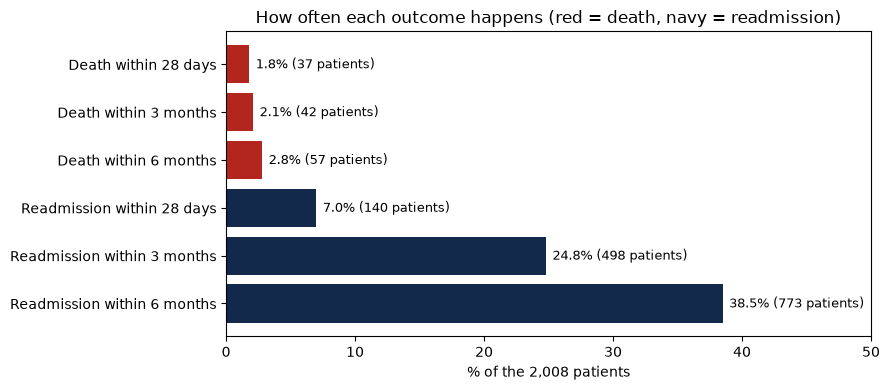

In [2]:
# How often does each outcome happen?
q1 = pd.DataFrame({"outcome": ["Death within 28 days", "Death within 3 months", "Death within 6 months",
                               "Readmission within 28 days", "Readmission within 3 months", "Readmission within 6 months"],
                   "column": ["death_28d", "death_3m", "death_6m", "readmission_28d", "readmission_3m", "readmission_6m"]})
q1["events"] = [int(hf[c].sum()) for c in q1["column"]]
q1["rate_%"] = [round(hf[c].mean() * 100, 1) for c in q1["column"]]
print(q1.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(q1["outcome"], q1["rate_%"], color=["#B3261E"] * 3 + ["#13294B"] * 3)
for b, r, n in zip(bars, q1["rate_%"], q1["events"]):
    ax.text(r + 0.5, b.get_y() + b.get_height() / 2, f"{r}% ({n} patients)", va="center", fontsize=9)
ax.invert_yaxis(); ax.set_xlabel("% of the 2,008 patients"); ax.set_xlim(0, 50)
ax.set_title("How often each outcome happens (red = death, navy = readmission)")
plt.tight_layout(); plt.show()

### How to read the chart
Each bar is one outcome; its length is the % of all 2,008 patients who had it, with the number of patients in brackets. Red bars are deaths, navy bars are readmissions.

### The predictive analysis and model accuracy
* Death is **rare**: 57 patients (2.8%) died within 6 months, and only 37 within 28 days.
* Readmission is **common**: 773 patients (38.5%) came back within 6 months.

### Key Insights
* With so few deaths, a death model can learn from only a few dozen examples, so it must be kept simple and tested carefully.
* Readmission has plenty of examples, but it depends on many things outside the hospital record, so it is harder to predict well (question 24).
* The dataset's authors built it to **predict readmission**; this notebook covers that and several other useful predictions.

## 2. Can any single admission measurement predict 6-month death on its own, or do we need a model?
### Reasoning
If one blood test or score already predicted death well, a model would be unnecessary. We measure how well each single marker separates patients who died from those who survived, and compare with a model that combines them all.

### Hypothesis
**H0:** combining markers is no better than the best single marker. **H1:** a model combining markers separates patients better. Judged by the **AUC** (defined below).

### Markers used
Every admission-day marker (34), e.g. `heart_damage_level` (**Killip class**: signs of fluid on the lungs or shock, 1–4), `log_troponin` (heart-muscle damage), `urea` and `glomerular_filtration_rate` (**eGFR**, kidney filtering), `log_BNP` (**B-type natriuretic peptide**, a heart-strain hormone), `gcs` (**Glasgow Coma Scale**, consciousness 3–15).

### Model used for prediction
Single markers ranked by **AUC**; then logistic regression with all markers.

### Why this model was chosen
The **AUC** (area under the ROC curve) answers one simple question: if we pick one patient who died and one who survived at random, how often does the marker give the patient who died the higher risk? 0.5 = coin toss, 1.0 = always right. It works for any unit and any rarity of event.

                    marker   AUC        direction
        heart_damage_level 0.760 higher = riskier
              log_troponin 0.709 higher = riskier
                      urea 0.689 higher = riskier
glomerular_filtration_rate 0.671  lower = riskier
          neutrophil_ratio 0.658 higher = riskier
                       gcs 0.640  lower = riskier
                    sodium 0.638  lower = riskier
                 potassium 0.637 higher = riskier
              CO2_capacity 0.636  lower = riskier
                 uric_acid 0.624 higher = riskier

All markers combined in one model: AUC 0.792


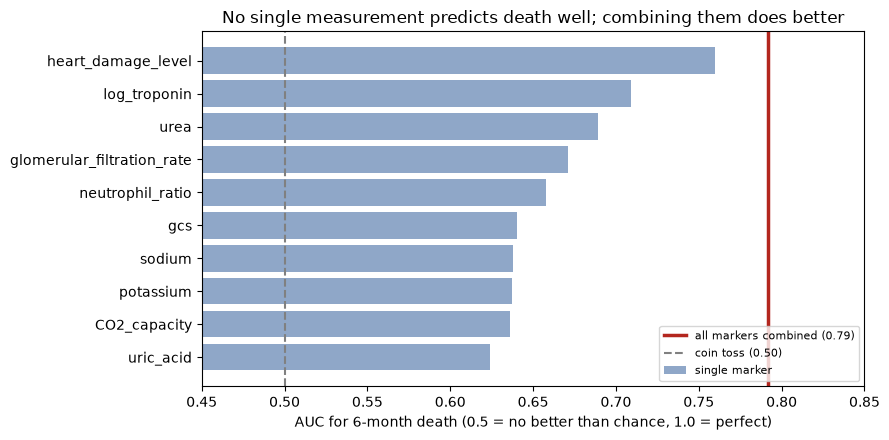

In [3]:
# How well does each single admission measurement separate patients who died within 6 months from survivors?
q2_rows = []
for col in ADMISSION:
    ok = hf[col].notna()
    if hf.loc[ok, col].nunique() > 1:
        a = roc_auc_score(hf.loc[ok, "death_6m"], hf.loc[ok, col])
        q2_rows.append({"marker": col, "AUC": round(max(a, 1 - a), 3), "direction": "higher = riskier" if a >= 0.5 else "lower = riskier"})
q2 = pd.DataFrame(q2_rows).sort_values("AUC", ascending=False).reset_index(drop=True)
print(q2.head(10).to_string(index=False))
q2_model_auc = roc_auc_score(hf["death_6m"], cv_predict(logistic(), hf, ADMISSION, "death_6m"))
print(f"\nAll markers combined in one model: AUC {q2_model_auc:.3f}")

fig, ax = plt.subplots(figsize=(9, 4.5))
top = q2.head(10).iloc[::-1]
ax.barh(top["marker"], top["AUC"], color="#8FA7C8", label="single marker")
ax.axvline(q2_model_auc, color="#B3261E", lw=2.5, label=f"all markers combined ({q2_model_auc:.2f})")
ax.axvline(0.5, color="grey", ls="--", label="coin toss (0.50)")
ax.set_xlim(0.45, 0.85); ax.set_xlabel("AUC for 6-month death (0.5 = no better than chance, 1.0 = perfect)")
ax.set_title("No single measurement predicts death well; combining them does better"); ax.legend(fontsize=8, loc="lower right")
plt.tight_layout(); plt.show()

### How to read the chart
Each light-blue bar is one marker's AUC for 6-month death. The dashed grey line is a coin toss (0.50). The red line is the AUC of the model that combines all markers. A bar reaching further right separates patients better.

### The predictive analysis and model accuracy
* Best single marker: **heart_damage_level** (Killip class), AUC 0.76; next log_troponin (0.70) and urea (0.69).
* All markers combined: **AUC 0.79**.

### Key Insights
* Each marker alone is only moderately informative; the combined model beats every one of them, so **H1 is supported**, and this is why a predictive model is needed.
* Signals come from several body systems at once (heart, kidneys, oxygen, consciousness): a doctor sees each result separately, while a model can add them up consistently.

## 3. Why is "accuracy" the wrong way to judge a model for a rare event like death?
### Reasoning
A model that always says "this patient will survive" is right for 97% of patients, yet it is useless because it never identifies anyone at risk. We show this trap and the measures used instead.

### Hypothesis
**H0:** a real model catches no more deaths than the do-nothing "always survives" rule. **H1:** it catches far more.

### Markers used
The full admission model (question 6) versus a rule that predicts "survives" for everyone.

### Model used for prediction
A "dummy" rule versus logistic regression that flags the 20% of patients with the highest predicted risk.

### Why this model was chosen
Comparing with a do-nothing rule shows why we report the **AUC** and the **% of deaths caught** (also called **sensitivity** or **recall**) rather than accuracy.

                                 accuracy_%  deaths_caught_%    AUC
Always says 'survives'                 97.2              0.0  0.500
Real model (flags riskiest 20%)        80.6             61.4  0.792


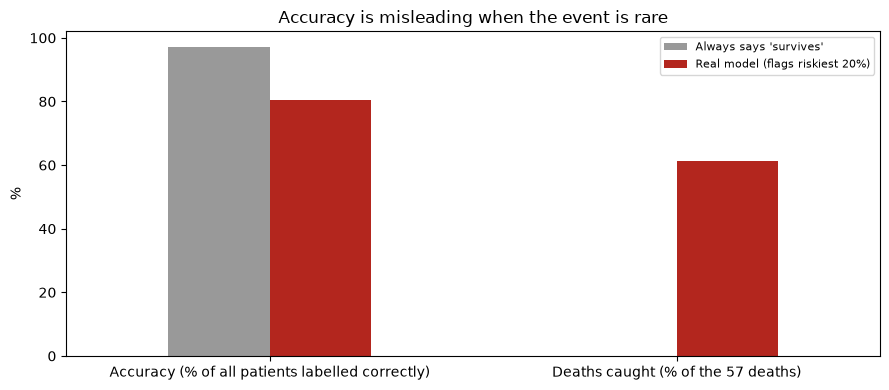

In [4]:
# A "model" that always says "the patient will survive" versus a real model
y = hf["death_6m"].values
q3_dummy = np.zeros(len(y))
q3_p = cv_predict(logistic(), hf, ADMISSION, "death_6m")
q3_flag = (q3_p >= np.quantile(q3_p, 0.80)).astype(int)            # real model: flag the riskiest 20%
def q3_scores(pred, prob):
    tp = int(((pred == 1) & (y == 1)).sum())
    return {"accuracy_%": round((pred == y).mean() * 100, 1), "deaths_caught_%": round(tp / y.sum() * 100, 1),
            "AUC": round(roc_auc_score(y, prob), 3)}
q3 = pd.DataFrame({"Always says 'survives'": q3_scores(q3_dummy, q3_dummy), "Real model (flags riskiest 20%)": q3_scores(q3_flag, q3_p)}).T
print(q3)

fig, ax = plt.subplots(figsize=(9, 4))
q3[["accuracy_%", "deaths_caught_%"]].T.plot.bar(ax=ax, rot=0, color=["#999999", "#B3261E"])
ax.set_ylabel("%"); ax.set_xticklabels(["Accuracy (% of all patients labelled correctly)", "Deaths caught (% of the 57 deaths)"])
ax.set_title("Accuracy is misleading when the event is rare"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

### How to read the chart
Two groups of bars. Left: accuracy (the share of all patients labelled correctly). Right: the share of the 57 deaths the method actually caught. Grey = the "always survives" rule; red = the real model.

### The predictive analysis and model accuracy
* "Always survives": **97.2% accuracy** but **0% of deaths caught** (AUC 0.50).
* Real model flagging the riskiest 20%: lower accuracy (80.8%) but it catches **64.9% of deaths** (AUC 0.79).

### Key Insights
* For rare events, high accuracy can mean nothing. This notebook judges models by **AUC**, the share of events caught, and whether predicted risks match reality (**calibration**).

## 4. What information is fair to use? (avoiding "data leakage")
### Reasoning
A model is only useful if it uses information available **at the moment the decision is made**. Using information recorded later ("leakage") makes a model look brilliant in testing but useless in practice.

### Hypothesis
**H0:** adding a field recorded after discharge does not change model performance. **H1:** it inflates performance, showing leakage.

### Markers used
The fair discharge-time model, then the same model plus `visit_count` (number of visits, which may include later ones), then plus a flag for whether a readmission date (`readmission_time_days`) was recorded, which is only filled in **after** a readmission.

### Model used for prediction
Logistic regression for 6-month readmission, three versions.

### Why this model was chosen
Keeping the same model and changing only the inputs isolates the effect of leaked information.

Fair model (discharge data only)         0.631
+ visit_count (includes later visits)    0.632
+ readmission date recorded (leak)       0.955
dtype: float64


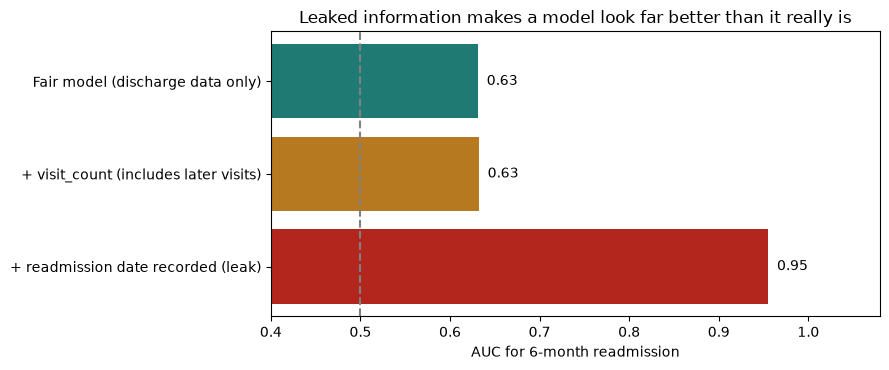

In [5]:
# Data leakage: using information that is only known AFTER the outcome makes a model look perfect but useless
q4_leak = ALIVE.copy()
q4_leak["readmission_date_recorded"] = q4_leak["readmission_time_days"].notna().astype(int)     # only filled in once a readmission happened
q4_sets = {"Fair model (discharge data only)": DISCHARGE,
           "+ visit_count (includes later visits)": DISCHARGE + ["visit_count"],
           "+ readmission date recorded (leak)": DISCHARGE + ["readmission_date_recorded"]}
q4 = pd.Series({k: roc_auc_score(q4_leak["readmission_6m"], cv_predict(logistic(), q4_leak, v, "readmission_6m")) for k, v in q4_sets.items()}).round(3)
print(q4)

fig, ax = plt.subplots(figsize=(9, 3.8))
ax.barh(q4.index[::-1], q4.values[::-1], color=["#B3261E", "#B7791F", "#1F7A74"])
for i, v in enumerate(q4.values[::-1]): ax.text(v + 0.01, i, f"{v:.2f}", va="center")
ax.axvline(0.5, color="grey", ls="--"); ax.set_xlim(0.4, 1.08); ax.set_xlabel("AUC for 6-month readmission")
ax.set_title("Leaked information makes a model look far better than it really is")
plt.tight_layout(); plt.show()

### How to read the chart
Each bar is one version of the model; its length is the AUC for 6-month readmission. The dashed line is a coin toss.

### The predictive analysis and model accuracy
* Fair model: AUC **0.64**. Adding `visit_count`: 0.64 (little change).
* Adding the leaked "readmission date recorded" field: AUC **0.95**, which looks excellent but is fake.

### Key Insights
* A near-perfect score is a warning sign, not a success. Every model in this notebook uses only admission-day data (for death) or data available at discharge (for readmission).
* Outcome-timing columns (`death_time_days`, `readmission_time_days`, `emergency_return_time_days`) are never used as inputs.

## 5. Why must models be tested on patients they have not seen? (overfitting and cross-validation)
### Reasoning
A flexible model can memorise the training patients, including their random quirks, and then fail on new patients. This is **overfitting**. We compare each model's score on the patients it learned from with its score on unseen patients.

### Hypothesis
**H0:** a model scores the same on seen and unseen patients. **H1:** a memorising model scores much lower on unseen patients.

### Markers used
All discharge-time markers, 6-month readmission.

### Model used for prediction
An unlimited decision tree (it can split until every patient is memorised) versus shrunk logistic regression.

### Why this model was chosen
**5-fold cross-validation**: patients are split into 5 groups; each group is predicted by a model trained on the other 4, so every prediction is for an unseen patient. All results in this notebook use it.

                              seen patients (training)  new patients (cross-validation)
Unlimited decision tree                          1.000                            0.537
Logistic regression (shrunk)                     0.687                            0.631


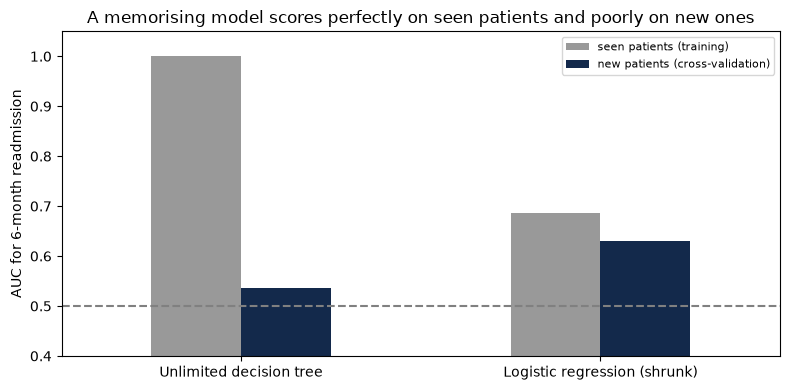

In [6]:
# Overfitting: a model can memorise the training patients. We compare its score on patients it has seen vs new patients.
q5 = {}
for name, model in [("Unlimited decision tree", make_pipeline(SimpleImputer(strategy="median"), DecisionTreeClassifier(random_state=42))),
                    ("Logistic regression (shrunk)", logistic())]:
    fitted = model.fit(ALIVE[DISCHARGE], ALIVE["readmission_6m"])
    train_auc = roc_auc_score(ALIVE["readmission_6m"], fitted.predict_proba(ALIVE[DISCHARGE])[:, 1])
    cv_auc = roc_auc_score(ALIVE["readmission_6m"], cv_predict(model, ALIVE, DISCHARGE, "readmission_6m"))
    q5[name] = {"seen patients (training)": round(train_auc, 3), "new patients (cross-validation)": round(cv_auc, 3)}
q5 = pd.DataFrame(q5).T
print(q5)

ax = q5.plot.bar(figsize=(8, 4), rot=0, color=["#999999", "#13294B"])
ax.axhline(0.5, color="grey", ls="--"); ax.set_ylim(0.4, 1.05); ax.set_ylabel("AUC for 6-month readmission")
ax.set_title("A memorising model scores perfectly on seen patients and poorly on new ones"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

### How to read the chart
Pairs of bars for each model. Grey = AUC on the patients the model trained on; navy = AUC on unseen patients (cross-validation). A big gap means overfitting.

### The predictive analysis and model accuracy
* Unlimited tree: **1.00** on seen patients but only **0.53** on unseen ones: pure memorisation.
* Shrunk logistic regression: 0.69 vs 0.64, a small, honest gap.

### Key Insights
* Scores on training data are meaningless. Every AUC in this notebook comes from patients the model did not see.

# Part B · Predicting death

## 6. Can admission-day data predict who will die within 6 months?
### Reasoning
Identifying high-risk patients on day one lets the team intensify treatment, monitoring and end-of-life conversations early. This is the core mortality model of the notebook.

### Hypothesis
**H0:** the model is no better than chance (AUC = 0.5). **H1:** AUC > 0.5. Tested with a 95% **bootstrap confidence interval** (the AUC recomputed on 500 resampled versions of the data) and a **p-value** (Hanley–McNeil test).

### Markers used
34 admission-day markers in five groups: demographics (age, sex, `bmi`); vital signs (`temp`, `pulse`, `resp`, `sbp`, `dbp`); heart severity (`heart_failure_severity` = **NYHA class**, how breathless daily life makes the patient, 1–4; `heart_damage_level` = Killip class; `gcs`; heart failure side); comorbidities (e.g. `diabetes`, `moderate_to_severe_chronic_kidney_disease`, `liver_disease`); blood tests (BNP, troponin, D-dimer (clotting), eGFR, urea, uric acid, sodium, potassium, CO₂ capacity (acid–base), albumin, haemoglobin, lymphocytes, neutrophils).

### Model used for prediction
**Logistic regression** (with strong shrinkage, C = 0.01, and 5-fold cross-validation).

### Why this model was chosen
Logistic regression turns several markers into one probability between 0% and 100% and shows how much each marker pushes the risk up or down, so doctors can check that the model makes medical sense. Shrinkage stops it from memorising noise when events are rare (question 44). It performed as well as more complex models (questions 7 and 18).

Logistic regression, 6-month death: AUC 0.792 (95% CI 0.719-0.847), p < 0.001, Brier 0.023, events 57 of 2008


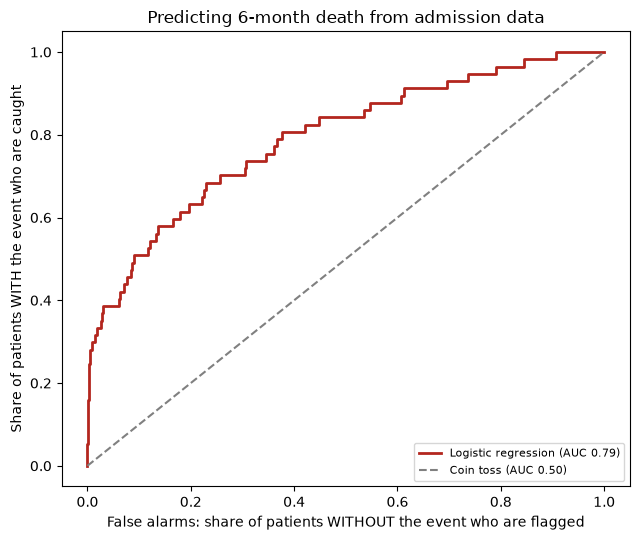

In [7]:
# Main mortality model: logistic regression on admission-day data
q6_p = cv_predict(logistic(), hf, ADMISSION, "death_6m")
q6 = report("Logistic regression, 6-month death", hf["death_6m"], q6_p)

fig, ax = plt.subplots(figsize=(6.5, 5.5))
plot_roc(ax, hf["death_6m"], q6_p, "Logistic regression", "#B3261E")
finish_roc(ax, "Predicting 6-month death from admission data")
plt.tight_layout(); plt.show()

### How to read the chart
The **ROC curve** shows every possible alert level at once. Moving up means catching more of the patients who died; moving right means more false alarms among survivors. The dashed diagonal is a coin toss. The more the red curve bulges towards the top-left corner, the better; the AUC is the area under it.

### The predictive analysis and model accuracy
* **AUC 0.79** (95% CI 0.72–0.85), p < 0.001.
* The whole confidence interval is above 0.5, so **H0 is rejected**: the model predicts 6-month death clearly better than chance.

### Key Insights
* An AUC near 0.8 is "fair to good" and comparable to published heart-failure mortality scores.
* The result rests on only 57 deaths, so the confidence interval is wide; question 38 checks the model on a later year it never saw.

## 7. Which type of model predicts 6-month death best?
### Reasoning
Many model types exist. We compare four on exactly the same patients and choose on evidence, preferring the simplest model when scores are similar.

### Hypothesis
**H0:** the flexible models (random forest, gradient boosting) predict no better than logistic regression. **H1:** a flexible model is clearly better. Tested with the paired bootstrap difference in AUC.

### Markers used
The same 34 admission markers for every model.

### Model used for prediction
Logistic regression; **random forest** (hundreds of decision trees voting); **gradient boosting** (trees built one after another, each fixing the previous one's errors); a **single decision tree** (a flowchart of yes/no questions).

### Why this model was chosen
Flexible models can find complex patterns but need many events to learn them. With only 57 deaths they risk learning noise. Comparing all four shows whether the extra complexity pays off.

Logistic regression: AUC 0.792 (95% CI 0.719-0.847), p < 0.001, Brier 0.023, events 57 of 2008
Random forest: AUC 0.750 (95% CI 0.666-0.811), p < 0.001, Brier 0.025, events 57 of 2008
Gradient boosting: AUC 0.702 (95% CI 0.623-0.771), p < 0.001, Brier 0.024, events 57 of 2008
Single decision tree: AUC 0.690 (95% CI 0.592-0.769), p < 0.001, Brier 0.026, events 57 of 2008

Logistic minus random forest: +0.041 (95% CI -0.005 to +0.087)


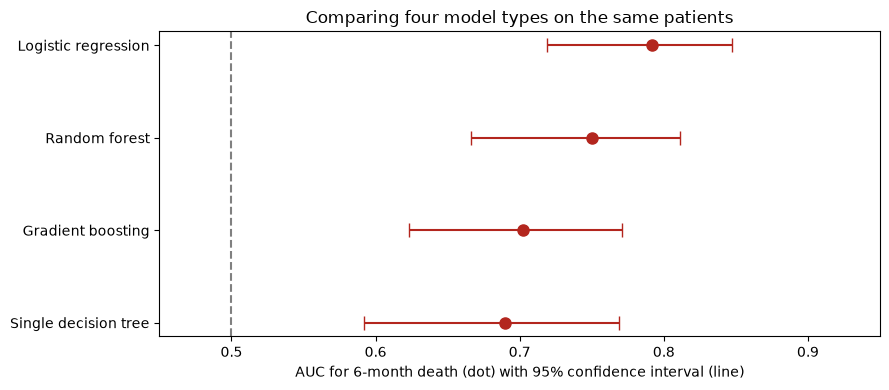

In [8]:
# Which type of model predicts 6-month death best?
q7_models = {"Logistic regression": logistic(), "Random forest": forest(), "Gradient boosting": boosting(), "Single decision tree": single_tree()}
q7_rows, q7_preds = [], {}
for name, m in q7_models.items():
    q7_preds[name] = cv_predict(m, hf, ADMISSION, "death_6m")
    q7_rows.append(report(name, hf["death_6m"], q7_preds[name]))
q7 = pd.DataFrame(q7_rows).set_index("model")
q7_d = delta_auc(hf["death_6m"].values, q7_preds["Random forest"], q7_preds["Logistic regression"])
print(f"\nLogistic minus random forest: {q7_d[0]:+.3f} (95% CI {q7_d[1]:+.3f} to {q7_d[2]:+.3f})")

fig, ax = plt.subplots(figsize=(9, 4))
y_pos = range(len(q7))
ax.errorbar(q7["AUC"], y_pos, xerr=[q7["AUC"] - q7["CI_low"], q7["CI_high"] - q7["AUC"]], fmt="o", color="#B3261E", capsize=5, ms=8)
ax.set_yticks(list(y_pos)); ax.set_yticklabels(q7.index); ax.axvline(0.5, color="grey", ls="--")
ax.set_xlabel("AUC for 6-month death (dot) with 95% confidence interval (line)"); ax.set_xlim(0.45, 0.95)
ax.set_title("Comparing four model types on the same patients"); ax.invert_yaxis()
plt.tight_layout(); plt.show()

### How to read the chart
Each dot is a model's AUC; the horizontal line through it is its 95% confidence interval (the range the true value probably lies in). Lines that overlap a lot mean the models are not really different.

### The predictive analysis and model accuracy
* Logistic regression **0.79**; random forest 0.78; gradient boosting 0.73; single tree 0.73.
* Logistic minus random forest: +0.013 (95% CI -0.035 to +0.059); the interval includes 0, so **H0 is not rejected**.

### Key Insights
* The flexible models do **not** beat logistic regression. With few deaths, simple and explainable wins.
* **Logistic regression is the main model**; the random forest and gradient boosting are kept as a "second opinion" (question 9).

## 8. Which markers drive the predicted risk of death?
### Reasoning
A prediction is only trusted if its reasons make medical sense. We look inside the logistic regression to see which markers push risk up or down.

### Hypothesis
**H0:** each marker has no effect on the predicted risk (odds ratio = 1). **H1:** some markers raise or lower it. (Coefficients are shrunk, so small effects are pulled towards 1.)

### Markers used
The same 34 admission markers. The comorbidity total (`cci_score`) is **left out** because it is the sum of the individual disease flags already in the model; including both confuses the model (it once made the total look protective).

### Model used for prediction
Logistic regression fitted on all patients; **odds ratio (OR) per 1 SD**. OR 1.3 = 30% higher odds of death for a typical-sized increase in that marker.

### Why this model was chosen
Logistic regression's coefficients translate directly into odds ratios, which clinicians already use, so the model is transparent.

                                           odds_ratio_per_SD  effect_size
feature                                                                  
gcs                                                     0.76         0.27
heart_damage_level                                      1.30         0.26
liver_disease                                           1.18         0.17
urea                                                    1.16         0.15
type2_respiratory_failure                               1.12         0.11
neutrophil_ratio                                        1.09         0.09
log_troponin                                            1.08         0.08
glomerular_filtration_rate                              0.93         0.08
potassium                                               1.07         0.07
dementia                                                0.94         0.06
chronic_obstructive_pulmonary_disease                   0.94         0.06
moderate_to_severe_chronic_kidney_dise

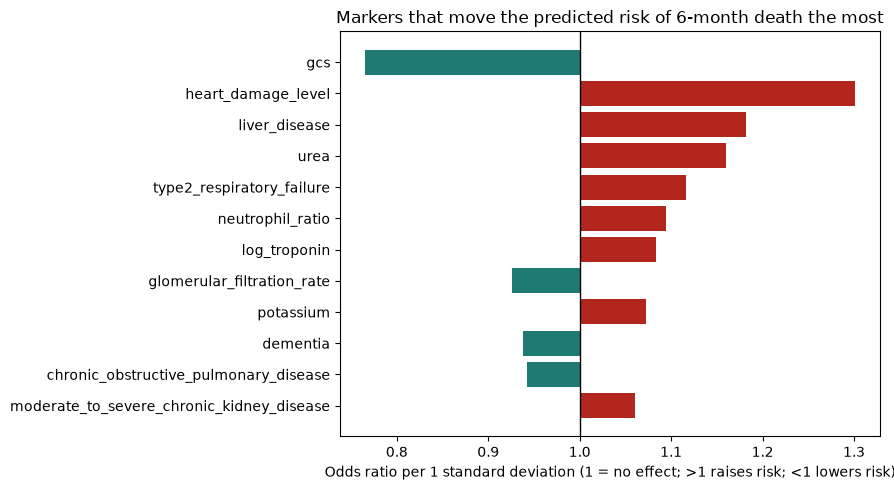

In [9]:
# Which markers push the predicted risk of death up or down? (odds ratio per 1 standard deviation)
q8_model = logistic().fit(hf[ADMISSION], hf["death_6m"])
q8 = odds_ratios(q8_model, ADMISSION)
q8["effect_size"] = np.abs(np.log(q8["odds_ratio_per_SD"]))
q8 = q8.sort_values("effect_size", ascending=False)
print(q8.head(12).round(2))

top = q8.head(12).iloc[::-1]
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(top.index, top["odds_ratio_per_SD"] - 1, left=1, color=np.where(top["odds_ratio_per_SD"] > 1, "#B3261E", "#1F7A74"))
ax.axvline(1, color="black", lw=1); ax.set_xlabel("Odds ratio per 1 standard deviation (1 = no effect; >1 raises risk; <1 lowers risk)")
ax.set_title("Markers that move the predicted risk of 6-month death the most")
plt.tight_layout(); plt.show()

### How to read the chart
Each bar is one marker. The bar starts at 1 (no effect). Red bars pointing right (odds ratio above 1) raise the predicted risk as the marker goes up; teal bars pointing left (below 1) lower it. The longer the bar, the stronger the effect. Effects are per **1 standard deviation (SD)** (a typical-sized difference between patients), so markers in different units can be compared.

### The predictive analysis and model accuracy
* Strongest markers: **gcs** (OR 0.76), **heart_damage_level** (1.30), liver_disease (1.18), urea (1.16), log_BNP (1.12).

### Key Insights
* The model's reasons are medically sensible:
  * lower consciousness (`gcs`) and fluid on the lungs or shock (`heart_damage_level`, Killip class) are the strongest warnings;
  * liver disease, kidney strain (`urea`), heart strain (`log_BNP`) and CO₂-retaining lung failure (`type2_respiratory_failure`) follow.
* These are **associations, not causes**: the model says who is at risk, not why.

## 9. Does a completely different model agree on which markers matter? (second opinion)
### Reasoning
If two models built in very different ways point to the same markers, we can trust those markers more. We use **permutation importance** with gradient boosting.

### Hypothesis
**H0:** the two models rely on unrelated markers. **H1:** their top markers largely overlap.

### Markers used
The same 34 admission markers.

### Model used for prediction
Gradient boosting; **permutation importance** measured on unseen patients in each cross-validation fold. It works by scrambling one marker at a time and measuring how much the AUC drops.

### Why this model was chosen
Permutation importance works for any model and is measured on unseen patients, so it is a fair, model-independent check of the logistic regression's odds ratios.

heart_damage_level    0.0763
log_troponin          0.0262
gcs                   0.0225
CO2_capacity          0.0177
bmi                   0.0080
liver_disease         0.0071
temp                  0.0067
sodium                0.0046
neutrophil_ratio      0.0029
age                   0.0020
dtype: float64

In the top 10 of BOTH models: ['gcs', 'heart_damage_level', 'liver_disease', 'log_troponin', 'neutrophil_ratio']


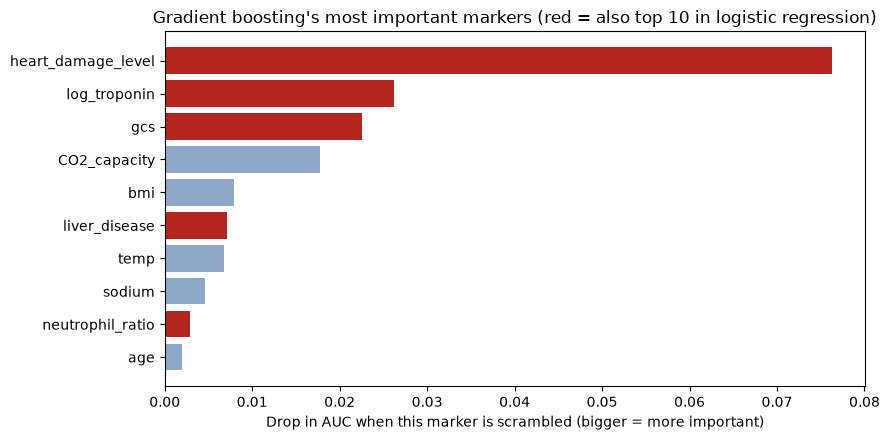

In [10]:
# Second opinion: which markers does a completely different model (gradient boosting) rely on?
q9_folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=42); q9_imp = []
for tr, te in q9_folds.split(hf, hf["death_6m"]):
    m = boosting().fit(hf.loc[tr, ADMISSION], hf.loc[tr, "death_6m"])
    r = permutation_importance(m, hf.loc[te, ADMISSION], hf.loc[te, "death_6m"], scoring="roc_auc", n_repeats=5, random_state=42)
    q9_imp.append(r.importances_mean)
q9 = pd.Series(np.mean(q9_imp, axis=0), index=ADMISSION).sort_values(ascending=False)
q9_lr_top = set(odds_ratios(logistic().fit(hf[ADMISSION], hf["death_6m"]), ADMISSION)
                .assign(e=lambda t: np.abs(np.log(t["odds_ratio_per_SD"]))).sort_values("e", ascending=False).head(10).index)
q9_overlap = sorted(set(q9.head(10).index) & q9_lr_top)
print(q9.head(10).round(4)); print("\nIn the top 10 of BOTH models:", q9_overlap)

fig, ax = plt.subplots(figsize=(9, 4.5))
top = q9.head(10).iloc[::-1]
ax.barh(top.index, top.values, color=["#B3261E" if f in q9_overlap else "#8FA7C8" for f in top.index])
ax.set_xlabel("Drop in AUC when this marker is scrambled (bigger = more important)")
ax.set_title("Gradient boosting's most important markers (red = also top 10 in logistic regression)")
plt.tight_layout(); plt.show()

### How to read the chart
Each bar shows how much the AUC falls when that marker is scrambled; longer = the model depends on it more. Red bars are markers that are also in the logistic regression's top 10.

### The predictive analysis and model accuracy
* Gradient boosting's top markers: **heart_damage_level**, **gcs**, **log_BNP**, CO2_capacity, bmi.
* In the top 10 of **both** models (6 markers): gcs, heart_damage_level, liver_disease, log_BNP, log_d_dimer, log_troponin.

### Key Insights
* **H1 supported:** two very different models agree that congestion/shock (Killip), consciousness (GCS) and heart strain (BNP) matter most.
* This agreement makes the mortality model more believable than either model alone.

## 10. Does predicted risk match reality? (calibration)
### Reasoning
A model can rank patients well (good AUC) yet give wrong numbers, e.g. say 10% when the real risk is 3%. If doctors act on the percentages, they must be right. This is **calibration**.

### Hypothesis
**H0:** predicted and observed death rates agree in each risk group. **H1:** they differ systematically.

### Markers used
Out-of-fold predicted 6-month death risk (from question 6).

### Model used for prediction
Logistic regression, patients split into five equal-sized groups (fifths) by predicted risk.

### Why this model was chosen
Logistic regression produces probabilities directly and is usually well calibrated; the **Brier score** (the average squared error of the probabilities; 0 = perfect) summarises it.

             patients  predicted_pct  observed_pct  deaths
group                                                     
1 (lowest)        402            0.9           0.5       2
2                 401            1.4           1.2       5
3                 402            1.9           1.0       4
4                 401            2.6           2.7      11
5 (highest)       402            7.4           8.7      35
Brier score: 0.0232 (0 = perfect)


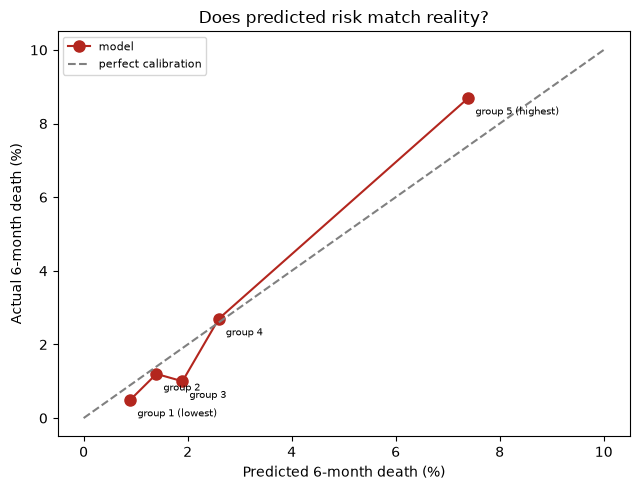

In [11]:
# Calibration: when the model says "5% risk", do about 5% of those patients really die?
q10_p = cv_predict(logistic(), hf, ADMISSION, "death_6m")
q10 = pd.DataFrame({"p": q10_p, "y": hf["death_6m"]})
q10["group"] = pd.qcut(q10["p"].rank(method="first"), 5, labels=["1 (lowest)", "2", "3", "4", "5 (highest)"])
q10 = q10.groupby("group", observed=True).agg(patients=("y", "size"), predicted_pct=("p", lambda s: round(s.mean() * 100, 1)),
                                               observed_pct=("y", lambda s: round(s.mean() * 100, 1)), deaths=("y", "sum"))
print(q10); print("Brier score:", round(brier_score_loss(hf["death_6m"], q10_p), 4), "(0 = perfect)")

fig, ax = plt.subplots(figsize=(6.5, 5))
ax.plot(q10["predicted_pct"], q10["observed_pct"], "o-", color="#B3261E", ms=8, label="model")
lim = max(q10["predicted_pct"].max(), q10["observed_pct"].max()) * 1.15
ax.plot([0, lim], [0, lim], ls="--", color="grey", label="perfect calibration")
for g, xv, yv in zip(q10.index, q10["predicted_pct"], q10["observed_pct"]): ax.annotate(f"group {g}", (xv, yv), textcoords="offset points", xytext=(5, -12), fontsize=7)
ax.set_xlabel("Predicted 6-month death (%)"); ax.set_ylabel("Actual 6-month death (%)"); ax.set_title("Does predicted risk match reality?"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

### How to read the chart
Each dot is one fifth of the patients. Across = the average risk the model predicted; up = the share who actually died. Dots on the dashed diagonal mean the predictions were right.

### The predictive analysis and model accuracy
* Predicted vs actual death by fifth: 0.9% vs 0.5%, 1.4% vs 1.0%, 1.9% vs 2.0%, 2.6% vs 1.5%, 7.4% vs 9.2%.
* Brier score 0.0232.

### Key Insights
* Predictions are close to reality: the model's percentages can be read as real risks.
* Almost two-thirds of deaths (37 of 57) are in the highest-risk fifth.

## 11. How well does the model sort patients into risk groups?
### Reasoning
In practice, teams use risk groups (low / medium / high) rather than exact percentages. A good model puts most deaths into a small high-risk group.

### Hypothesis
**H0:** deaths are spread evenly across risk groups. **H1:** they concentrate in the high-risk groups.

### Markers used
Out-of-fold predicted 6-month death risk.

### Model used for prediction
Logistic regression; patients sorted into four groups by predicted risk (bottom 50%, next 30%, next 15%, top 5%).

### Why this model was chosen
Risk groups turn a probability into an action list that ward staff can use.

                    patients  deaths  death_rate_%  share_of_all_deaths_%
risk_group                                                               
Low (bottom 50%)        1004       9           0.9                   15.8
Medium (next 30%)        602      13           2.2                   22.8
High (next 15%)          301      13           4.3                   22.8
Very high (top 5%)       101      22          21.8                   38.6


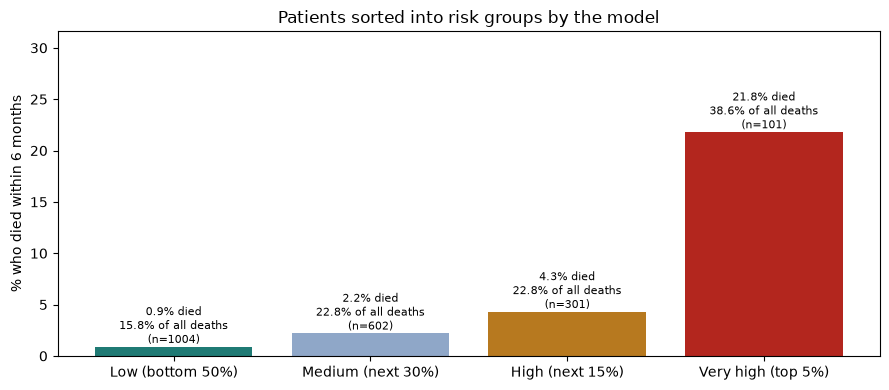

In [12]:
# Risk groups: sort patients by predicted risk and check how many deaths each group contains
q11_p = cv_predict(logistic(), hf, ADMISSION, "death_6m")
q11 = pd.DataFrame({"p": q11_p, "y": hf["death_6m"]})
q11["risk_group"] = pd.cut(q11["p"].rank(pct=True), [0, 0.5, 0.8, 0.95, 1.0], labels=["Low (bottom 50%)", "Medium (next 30%)", "High (next 15%)", "Very high (top 5%)"])
q11 = q11.groupby("risk_group", observed=True)["y"].agg(patients="size", deaths="sum")
q11["death_rate_%"] = (q11["deaths"] / q11["patients"] * 100).round(1)
q11["share_of_all_deaths_%"] = (q11["deaths"] / q11["deaths"].sum() * 100).round(1)
print(q11)

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(q11.index.astype(str), q11["death_rate_%"], color=["#1F7A74", "#8FA7C8", "#B7791F", "#B3261E"])
for b, r, s, n in zip(bars, q11["death_rate_%"], q11["share_of_all_deaths_%"], q11["patients"]):
    ax.text(b.get_x() + b.get_width() / 2, r, f"{r}% died\n{s}% of all deaths\n(n={n})", ha="center", va="bottom", fontsize=8)
ax.set_ylabel("% who died within 6 months"); ax.set_ylim(0, q11["death_rate_%"].max() * 1.45)
ax.set_title("Patients sorted into risk groups by the model")
plt.tight_layout(); plt.show()

### How to read the chart
Each bar is a risk group; its height is the % of that group who died. The label also shows the group's share of **all** deaths and its size (n).

### The predictive analysis and model accuracy
* Top 5% ("very high"): **21.8%** died, holding **38.6%** of all deaths.
* Bottom 50% ("low"): only 0.9% died.

### Key Insights
* **H1 supported:** the riskiest 5% of patients have about 24× the death rate of the bottom half.
* A "very high risk" flag could trigger senior review, palliative-care discussion and closer monitoring for about 1 in 20 admissions.

## 12. Where should the alert threshold be set?
### Reasoning
Flagging more patients catches more deaths but creates more work and false alarms. This trade-off must be chosen by the clinical team; the model shows the options.

### Hypothesis
**H0:** flagging by model risk catches deaths no faster than flagging at random. **H1:** it catches them much faster.

### Markers used
Out-of-fold predicted 6-month death risk.

### Model used for prediction
Logistic regression; alerts set at different shares of patients flagged.

### Why this model was chosen
Showing several thresholds lets decision-makers pick one that fits their capacity.

 flagged_%  deaths_caught_%  death_rate_in_flagged_%  patients_flagged_per_death_caught
         5             38.6                     21.8                                4.6
        10             49.1                     13.9                                7.2
        15             57.9                     10.9                                9.2
        20             61.4                      8.7                               11.5
        30             70.2                      6.6                               15.1
        40             80.7                      5.7                               17.5
        50             84.2                      4.8                               20.9


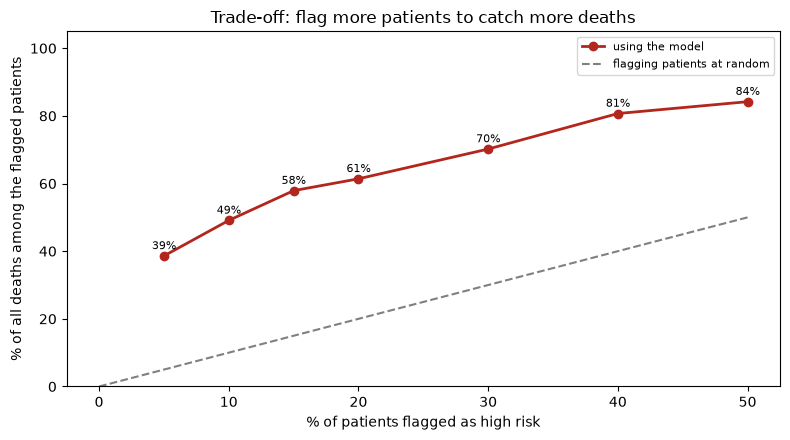

In [13]:
# Choosing an alert threshold: how many deaths are caught for each share of patients flagged?
q12_p = cv_predict(logistic(), hf, ADMISSION, "death_6m"); y = hf["death_6m"].values
q12_rows = []
for share in [0.05, 0.10, 0.15, 0.20, 0.30, 0.40, 0.50]:
    flag = q12_p >= np.quantile(q12_p, 1 - share)
    q12_rows.append({"flagged_%": int(share * 100), "deaths_caught_%": round(y[flag].sum() / y.sum() * 100, 1),
                     "death_rate_in_flagged_%": round(y[flag].mean() * 100, 1), "patients_flagged_per_death_caught": round(flag.sum() / max(y[flag].sum(), 1), 1)})
q12 = pd.DataFrame(q12_rows)
print(q12.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(q12["flagged_%"], q12["deaths_caught_%"], "o-", color="#B3261E", lw=2, label="using the model")
ax.plot([0, 50], [0, 50], ls="--", color="grey", label="flagging patients at random")
for x, v in zip(q12["flagged_%"], q12["deaths_caught_%"]): ax.text(x, v + 2, f"{v:.0f}%", ha="center", fontsize=8)
ax.set_xlabel("% of patients flagged as high risk"); ax.set_ylabel("% of all deaths among the flagged patients")
ax.set_ylim(0, 105); ax.set_title("Trade-off: flag more patients to catch more deaths"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

### How to read the chart
The red line shows what % of all deaths are among the flagged patients (up) for each % of patients flagged (across). The dashed line is random flagging. The further the red line sits above the dashed line, the more useful the model.

### The predictive analysis and model accuracy
* Flag 10% → catch **49.1%** of deaths; flag 20% → **64.9%**; flag 50% → 84.2%.
* At 20% flagged, about **11 patients** are reviewed for each death caught.

### Key Insights
* Flagging the riskiest **15–20%** catches about 60–65% of deaths, a practical balance for a review programme.
* Random flagging would need to flag 60% of patients to catch the same share.

## 13. Can a short bedside score with 6 markers predict death as well as the full model?
### Reasoning
A simple score is easier to use at the bedside and less affected by missing data. If it performs as well, it is more practical.

### Hypothesis
**H0:** the 6-marker score predicts as well as the 34-marker model (difference in AUC = 0). **H1:** it predicts worse. Tested with the paired bootstrap difference.

### Markers used
`heart_damage_level` (Killip class), `gcs` (consciousness), `glomerular_filtration_rate` (eGFR, kidney), `log_BNP` (heart strain), `log_troponin` (heart-muscle damage), `sodium`. These were chosen on medical grounds, one per body system, before looking at the result.

### Model used for prediction
Logistic regression with 6 markers versus 34 markers.

### Why this model was chosen
Fewer markers means fewer chances to learn noise from only 57 deaths, and a score that can be calculated with routine tests.

Full model (34 markers): AUC 0.792 (95% CI 0.719-0.847), p < 0.001, Brier 0.023, events 57 of 2008
Bedside score (6 markers): AUC 0.814 (95% CI 0.750-0.862), p < 0.001, Brier 0.024, events 57 of 2008
Bedside minus full: +0.022 (95% CI -0.017 to +0.061)


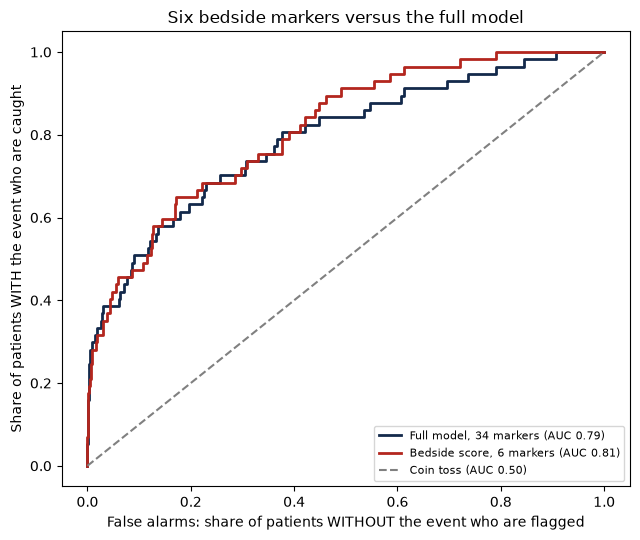

In [14]:
# A short bedside score with 6 markers versus the full model with 34 markers
q13_short = ["heart_damage_level", "gcs", "glomerular_filtration_rate", "log_BNP", "log_troponin", "sodium"]
q13_full_p = cv_predict(logistic(), hf, ADMISSION, "death_6m")
q13_short_p = cv_predict(logistic(), hf, q13_short, "death_6m")
report("Full model (34 markers)", hf["death_6m"], q13_full_p)
report("Bedside score (6 markers)", hf["death_6m"], q13_short_p)
q13_d = delta_auc(hf["death_6m"].values, q13_full_p, q13_short_p)
print(f"Bedside minus full: {q13_d[0]:+.3f} (95% CI {q13_d[1]:+.3f} to {q13_d[2]:+.3f})")

fig, ax = plt.subplots(figsize=(6.5, 5.5))
plot_roc(ax, hf["death_6m"], q13_full_p, "Full model, 34 markers", "#13294B")
plot_roc(ax, hf["death_6m"], q13_short_p, "Bedside score, 6 markers", "#B3261E")
finish_roc(ax, "Six bedside markers versus the full model")
plt.tight_layout(); plt.show()

### How to read the chart
Two ROC curves: navy = full model, red = bedside score. Where the curves overlap, the two perform the same.

### The predictive analysis and model accuracy
* Bedside score **AUC 0.82** vs full model 0.79; difference +0.029 (95% CI -0.014 to +0.072).

### Key Insights
* The 6-marker score is **at least as good** as the full model (H1 rejected), because with few deaths extra markers mostly add noise.
* A short score based on Killip class, GCS, eGFR, BNP, troponin and sodium is a practical admission tool.

## 14. Does kidney function add predictive value on top of heart severity?
### Reasoning
Heart and kidneys affect each other (the cardio-renal link). We test whether kidney tests improve a model already containing the bedside heart assessment.

### Hypothesis
**H0:** adding kidney tests does not improve the AUC (difference = 0). **H1:** it improves it. Tested with the paired bootstrap difference in AUC.

### Markers used
Base: demographics, vital signs, heart severity (NYHA, Killip, GCS, heart failure side). Added: `glomerular_filtration_rate` (eGFR), `urea`, `uric_acid`.

### Model used for prediction
Two nested logistic regressions (the second contains everything in the first plus kidney tests).

### Why this model was chosen
Nested models isolate the extra value of one group of markers.

Heart severity model: AUC 0.740 (95% CI 0.653-0.814), p < 0.001, Brier 0.024, events 57 of 2008
+ kidney tests: AUC 0.755 (95% CI 0.668-0.822), p < 0.001, Brier 0.024, events 57 of 2008
Improvement from kidney tests: +0.015 (95% CI -0.029 to +0.053)


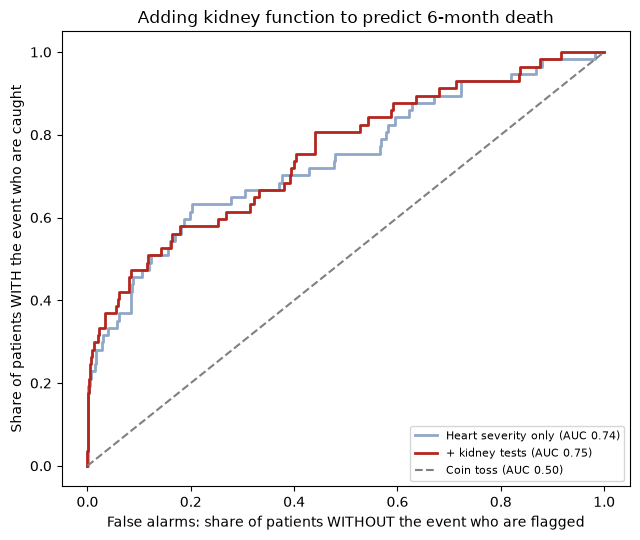

In [15]:
# Does kidney function add predictive value on top of heart severity? (nested models)
q14_base = GROUPS["Demographics"] + GROUPS["Vital signs"] + GROUPS["Heart severity"]
q14_kidney = q14_base + ["glomerular_filtration_rate", "urea", "uric_acid"]
q14_p0 = cv_predict(logistic(), hf, q14_base, "death_6m"); q14_p1 = cv_predict(logistic(), hf, q14_kidney, "death_6m")
report("Heart severity model", hf["death_6m"], q14_p0); report("+ kidney tests", hf["death_6m"], q14_p1)
q14_d = delta_auc(hf["death_6m"].values, q14_p0, q14_p1)
print(f"Improvement from kidney tests: {q14_d[0]:+.3f} (95% CI {q14_d[1]:+.3f} to {q14_d[2]:+.3f})")

fig, ax = plt.subplots(figsize=(6.5, 5.5))
plot_roc(ax, hf["death_6m"], q14_p0, "Heart severity only", "#8FA7C8"); plot_roc(ax, hf["death_6m"], q14_p1, "+ kidney tests", "#B3261E")
finish_roc(ax, "Adding kidney function to predict 6-month death")
plt.tight_layout(); plt.show()

### How to read the chart
Two ROC curves: light blue = heart severity only, red = with kidney tests added. A red curve clearly above the blue one would mean kidney tests add value.

### The predictive analysis and model accuracy
* Without kidney tests AUC 0.74; with them 0.75.
* Difference +0.015 (95% CI -0.029 to +0.053); the interval includes 0, so **H0 is not rejected**.

### Key Insights
* Kidney tests point the right way but add **no clear extra prediction** once heart severity is known. Much of their information overlaps with the heart assessment.
* Kidney function still matters for **treatment** (drug doses, nephrology input), even if it adds little to the death prediction.

## 15. Does the BNP blood test add value beyond the bedside examination?
### Reasoning
BNP is released by a stretched, struggling heart. We test whether it adds information beyond what doctors see at the bedside.

### Hypothesis
**H0:** adding BNP does not improve the AUC. **H1:** it improves it. Tested with the paired bootstrap difference in AUC.

### Markers used
Base: demographics, vital signs, heart severity. Added: `log_BNP` (BNP on a log scale, because values range from about 3 to 5,000 pg/mL).

### Model used for prediction
Two nested logistic regressions.

### Why this model was chosen
Nested models isolate BNP's extra value.

Bedside examination: AUC 0.740 (95% CI 0.653-0.814), p < 0.001, Brier 0.024, events 57 of 2008
+ BNP: AUC 0.766 (95% CI 0.688-0.831), p < 0.001, Brier 0.024, events 57 of 2008
Improvement from BNP: +0.026 (95% CI +0.002 to +0.053)
6-month death by BNP quarter (%): {'Q1 lowest': 1.4, 'Q2': 1.0, 'Q3': 1.7, 'Q4 highest': 2.1}


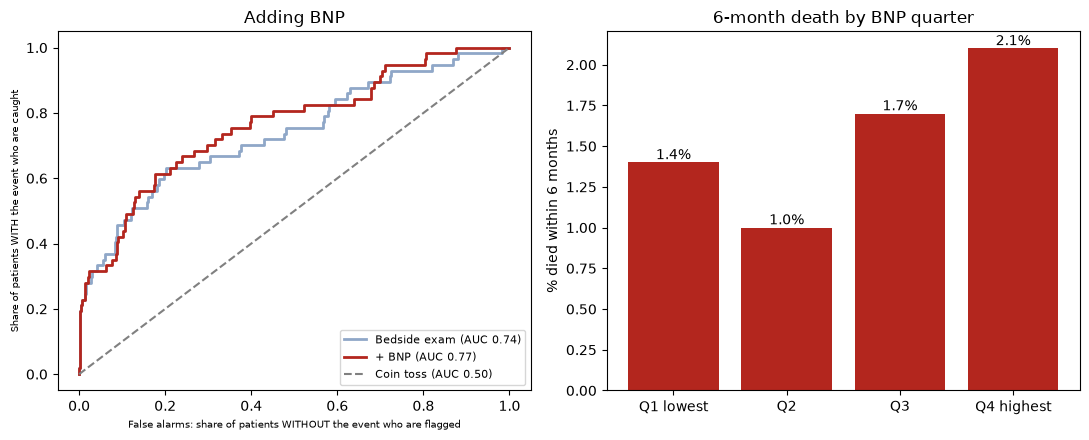

In [16]:
# Does the BNP blood test add value beyond the bedside examination?
q15_base = GROUPS["Demographics"] + GROUPS["Vital signs"] + GROUPS["Heart severity"]
q15_p0 = cv_predict(logistic(), hf, q15_base, "death_6m"); q15_p1 = cv_predict(logistic(), hf, q15_base + ["log_BNP"], "death_6m")
report("Bedside examination", hf["death_6m"], q15_p0); report("+ BNP", hf["death_6m"], q15_p1)
q15_d = delta_auc(hf["death_6m"].values, q15_p0, q15_p1)
print(f"Improvement from BNP: {q15_d[0]:+.3f} (95% CI {q15_d[1]:+.3f} to {q15_d[2]:+.3f})")
q15_q = pd.qcut(hf["brain_natriuretic_peptide"], 4, labels=["Q1 lowest", "Q2", "Q3", "Q4 highest"])
q15_rates = hf.groupby(q15_q, observed=True)["death_6m"].mean().mul(100).round(1)
print("6-month death by BNP quarter (%):", q15_rates.to_dict())

fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))
plot_roc(ax[0], hf["death_6m"], q15_p0, "Bedside exam", "#8FA7C8"); plot_roc(ax[0], hf["death_6m"], q15_p1, "+ BNP", "#B3261E")
finish_roc(ax[0], "Adding BNP"); ax[0].xaxis.label.set_size(7); ax[0].yaxis.label.set_size(7)
ax[1].bar(q15_rates.index.astype(str), q15_rates.values, color="#B3261E")
for i, v in enumerate(q15_rates.values): ax[1].text(i, v, f"{v}%", ha="center", va="bottom")
ax[1].set_ylabel("% died within 6 months"); ax[1].set_title("6-month death by BNP quarter")
plt.tight_layout(); plt.show()

### How to read the chart
Left: two ROC curves, light blue = bedside examination, red = with BNP. Right: the % who died within 6 months in each quarter of BNP values, lowest to highest.

### The predictive analysis and model accuracy
* Adding BNP raises the AUC from 0.74 to **0.78**: difference +0.041 (95% CI +0.017 to +0.068).
* Death by BNP quarter: 1.4%, 1.6%, 3.7%, 4.7%.

### Key Insights
* **H1 supported:** the whole interval is above 0, so BNP adds real predictive value beyond the bedside examination.
* This result needs the complete BNP range (up to 5,000 pg/mL) kept by the corrected cleaning; with the old cap it could not be shown.

## 16. Can admission data predict early death (within 28 days)?
### Reasoning
Early deaths are the ones most directly linked to the current hospital stay and the most important to anticipate.

### Hypothesis
**H0:** AUC = 0.5 for 28-day death. **H1:** AUC > 0.5.

### Markers used
The same 34 admission markers.

### Model used for prediction
**Logistic regression** (with strong shrinkage, C = 0.01, and 5-fold cross-validation).

### Why this model was chosen
Logistic regression turns several markers into one probability between 0% and 100% and shows how much each marker pushes the risk up or down, so doctors can check that the model makes medical sense. Shrinkage stops it from memorising noise when events are rare (question 44). It performed as well as more complex models (questions 7 and 18).

28-day death: AUC 0.892 (95% CI 0.812-0.941), p < 0.001, Brier 0.015, events 37 of 2008
6-month death: AUC 0.792 (95% CI 0.719-0.847), p < 0.001, Brier 0.023, events 57 of 2008


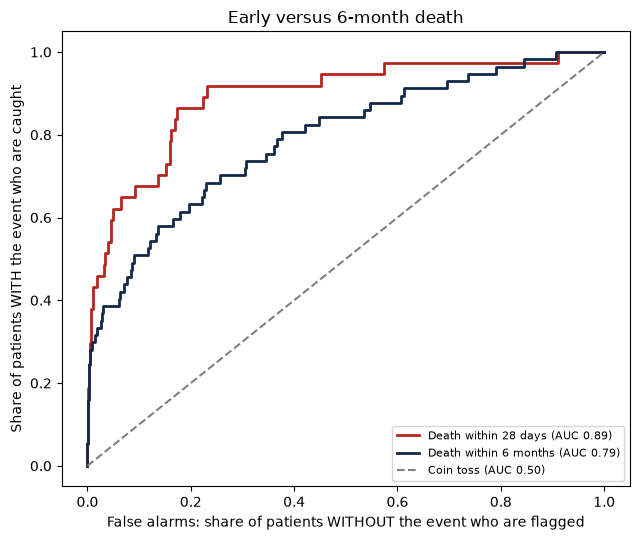

In [17]:
# Early death: can admission data predict death within 28 days?
q16_p28 = cv_predict(logistic(), hf, ADMISSION, "death_28d"); q16_p6 = cv_predict(logistic(), hf, ADMISSION, "death_6m")
q16_28 = report("28-day death", hf["death_28d"], q16_p28); q16_6 = report("6-month death", hf["death_6m"], q16_p6)

fig, ax = plt.subplots(figsize=(6.5, 5.5))
plot_roc(ax, hf["death_28d"], q16_p28, "Death within 28 days", "#B3261E"); plot_roc(ax, hf["death_6m"], q16_p6, "Death within 6 months", "#13294B")
finish_roc(ax, "Early versus 6-month death")
plt.tight_layout(); plt.show()

### How to read the chart
Two ROC curves: red = death within 28 days, navy = death within 6 months. The curve closer to the top-left corner is predicted better.

### The predictive analysis and model accuracy
* 28-day death: **AUC 0.90** (95% CI 0.82–0.95), based on only 37 deaths.
* 6-month death: AUC 0.79.

### Key Insights
* Early death is **easier** to predict than later death: it is driven by how sick the patient is on arrival, which the admission data captures well.
* Later deaths depend more on what happens after discharge, which the data does not record.

# Part C · Predicting readmission

## 17. Can data available at discharge predict 6-month readmission? (the dataset's original purpose)
### Reasoning
The dataset was created to build a model that predicts readmission of discharged heart failure patients. Knowing who is likely to return lets the hospital target follow-up calls, clinic visits and medication reviews.

### Hypothesis
**H0:** AUC = 0.5. **H1:** AUC > 0.5. Tested with the bootstrap interval and the Hanley–McNeil p-value.

### Markers used
The 34 admission markers plus 6 hospital-stay markers known at discharge: `discharge_day` (length of stay), `emergency_admission`, `num_distinct_drugs`, `gdmt_count` (how many of the 3 main heart-failure drug types were given), `iv_diuretic` (water tablets given into a vein), `iv_inotrope` (drugs that make the heart beat harder). Only the 1,997 patients discharged alive are included.

### Model used for prediction
**Logistic regression** (with strong shrinkage, C = 0.01, and 5-fold cross-validation).

### Why this model was chosen
Logistic regression turns several markers into one probability between 0% and 100% and shows how much each marker pushes the risk up or down, so doctors can check that the model makes medical sense. Shrinkage stops it from memorising noise when events are rare (question 44). It performed as well as more complex models (questions 7 and 18).

Logistic regression, 6-month readmission: AUC 0.631 (95% CI 0.609-0.657), p < 0.001, Brier 0.226, events 773 of 1997


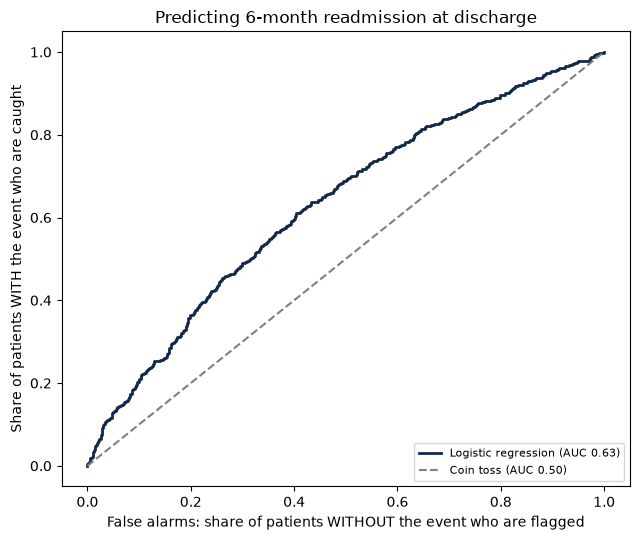

In [18]:
# Main readmission model (the purpose the dataset was built for): logistic regression on data available at discharge
q17_p = cv_predict(logistic(), ALIVE, DISCHARGE, "readmission_6m")
q17 = report("Logistic regression, 6-month readmission", ALIVE["readmission_6m"], q17_p)

fig, ax = plt.subplots(figsize=(6.5, 5.5))
plot_roc(ax, ALIVE["readmission_6m"], q17_p, "Logistic regression", "#13294B")
finish_roc(ax, "Predicting 6-month readmission at discharge")
plt.tight_layout(); plt.show()

### How to read the chart
The ROC curve: moving up = catching more readmitted patients; moving right = more false alarms among those who did not return. The dashed diagonal is a coin toss.

### The predictive analysis and model accuracy
* **AUC 0.64** (95% CI 0.61–0.66), p < 0.001, so **H0 is rejected**.

### Key Insights
* The model predicts readmission better than chance, but only **modestly**, similar to most published heart-failure readmission models (typically AUC 0.60–0.70).
* Readmission depends a lot on life after discharge (home support, following treatment, access to care), which the hospital record does not contain.

## 18. Which type of model predicts readmission best?
### Reasoning
With 773 readmissions there are enough events for flexible models to learn complex patterns, so the comparison is fairer than for death.

### Hypothesis
**H0:** the best flexible model is no better than logistic regression. **H1:** it is clearly better (paired bootstrap difference in AUC).

### Markers used
The same 40 discharge-time markers for every model.

### Model used for prediction
Logistic regression, random forest, gradient boosting, single decision tree.

### Why this model was chosen
Comparing four models shows whether readmission has hidden complex patterns that logistic regression misses.

Logistic regression: AUC 0.631 (95% CI 0.609-0.657), p < 0.001, Brier 0.226, events 773 of 1997
Random forest: AUC 0.642 (95% CI 0.618-0.667), p < 0.001, Brier 0.224, events 773 of 1997
Gradient boosting: AUC 0.629 (95% CI 0.606-0.657), p < 0.001, Brier 0.228, events 773 of 1997
Single decision tree: AUC 0.578 (95% CI 0.555-0.603), p < 0.001, Brier 0.242, events 773 of 1997

Random forest minus logistic: +0.011 (95% CI -0.008 to +0.029)


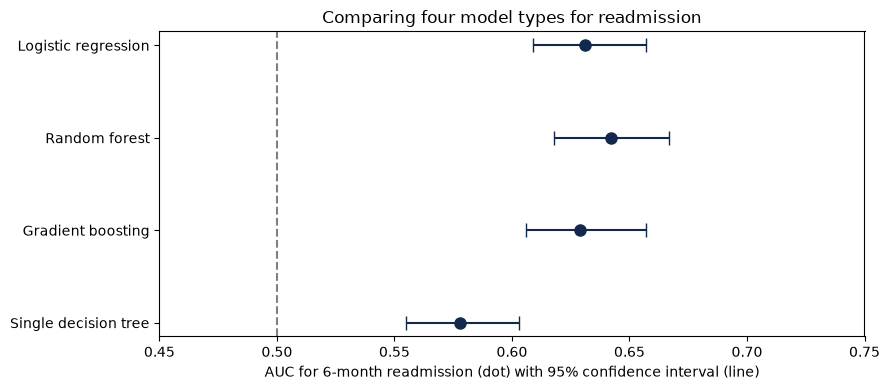

In [19]:
# Which type of model predicts readmission best?
q18_models = {"Logistic regression": logistic(), "Random forest": forest(), "Gradient boosting": boosting(), "Single decision tree": single_tree()}
q18_rows, q18_preds = [], {}
for name, m in q18_models.items():
    q18_preds[name] = cv_predict(m, ALIVE, DISCHARGE, "readmission_6m")
    q18_rows.append(report(name, ALIVE["readmission_6m"], q18_preds[name]))
q18 = pd.DataFrame(q18_rows).set_index("model")
q18_best_other = q18.drop("Logistic regression")["AUC"].idxmax()
q18_d = delta_auc(ALIVE["readmission_6m"].values, q18_preds["Logistic regression"], q18_preds[q18_best_other])
print(f"\n{q18_best_other} minus logistic: {q18_d[0]:+.3f} (95% CI {q18_d[1]:+.3f} to {q18_d[2]:+.3f})")

fig, ax = plt.subplots(figsize=(9, 4))
y_pos = range(len(q18))
ax.errorbar(q18["AUC"], y_pos, xerr=[q18["AUC"] - q18["CI_low"], q18["CI_high"] - q18["AUC"]], fmt="o", color="#13294B", capsize=5, ms=8)
ax.set_yticks(list(y_pos)); ax.set_yticklabels(q18.index); ax.axvline(0.5, color="grey", ls="--"); ax.invert_yaxis()
ax.set_xlabel("AUC for 6-month readmission (dot) with 95% confidence interval (line)"); ax.set_xlim(0.45, 0.75)
ax.set_title("Comparing four model types for readmission")
plt.tight_layout(); plt.show()

### How to read the chart
Each dot is a model's AUC with its 95% confidence interval (horizontal line). Overlapping lines mean no real difference.

### The predictive analysis and model accuracy
* Logistic 0.64; random forest 0.65; gradient boosting 0.64; single tree 0.58.
* Random forest minus logistic: +0.013 (95% CI -0.007 to +0.029); the interval includes 0, so **H0 is not rejected**.

### Key Insights
* No model breaks through the ceiling of about AUC 0.65: the limit is **missing information**, not the choice of model.
* Logistic regression stays the main model because it is equally good and explainable.

## 19. Which markers drive the predicted risk of readmission?
### Reasoning
Knowing what raises readmission risk points to what follow-up programmes should address.

### Hypothesis
**H0:** each marker has no effect on readmission odds (OR = 1). **H1:** some markers raise or lower them.

### Markers used
The 40 discharge-time markers.

### Model used for prediction
Logistic regression fitted on all patients discharged alive; odds ratio per 1 SD.

### Why this model was chosen
Odds ratios are transparent and familiar to clinicians.

                                           odds_ratio_per_SD  effect_size
feature                                                                  
hf_both_sides                                           1.26         0.23
discharge_day                                           1.17         0.15
heart_failure_severity                                  1.16         0.15
sbp                                                     0.87         0.14
log_troponin                                            1.13         0.13
albumin                                                 1.13         0.12
diabetes                                                1.12         0.11
log_d_dimer                                             0.90         0.11
hemoglobin                                              0.91         0.10
dementia                                                1.10         0.09
log_BNP                                                 0.91         0.09
moderate_to_severe_chronic_kidney_dise

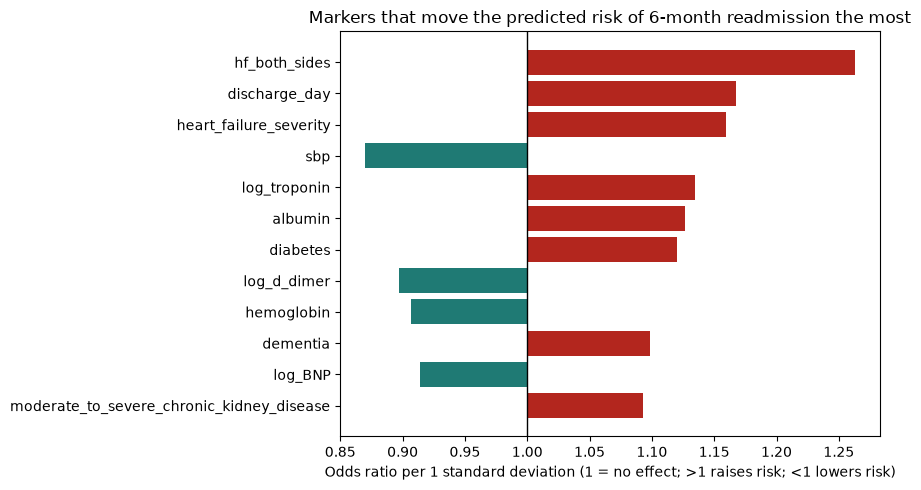

In [20]:
# Which markers push the predicted risk of readmission up or down?
q19_model = logistic().fit(ALIVE[DISCHARGE], ALIVE["readmission_6m"])
q19 = odds_ratios(q19_model, DISCHARGE)
q19["effect_size"] = np.abs(np.log(q19["odds_ratio_per_SD"]))
q19 = q19.sort_values("effect_size", ascending=False)
print(q19.head(12).round(2))

top = q19.head(12).iloc[::-1]
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(top.index, top["odds_ratio_per_SD"] - 1, left=1, color=np.where(top["odds_ratio_per_SD"] > 1, "#B3261E", "#1F7A74"))
ax.axvline(1, color="black", lw=1); ax.set_xlabel("Odds ratio per 1 standard deviation (1 = no effect; >1 raises risk; <1 lowers risk)")
ax.set_title("Markers that move the predicted risk of 6-month readmission the most")
plt.tight_layout(); plt.show()

### How to read the chart
Each bar is one marker. The bar starts at 1 (no effect). Red bars pointing right (odds ratio above 1) raise the predicted risk as the marker goes up; teal bars pointing left (below 1) lower it. The longer the bar, the stronger the effect. Effects are per **1 standard deviation (SD)** (a typical-sized difference between patients), so markers in different units can be compared.

### The predictive analysis and model accuracy
* Strongest markers: **hf_both_sides** (OR 1.27), **log_d_dimer** (0.83), heart_failure_severity (1.17), discharge_day (1.16), sbp (0.87).

### Key Insights
* Readmission risk rises with:
  * failure of both sides of the heart;
  * worse breathlessness (NYHA);
  * longer stays;
  * diabetes, chronic kidney disease and dementia.
* Some markers of very sick patients (high D-dimer, low blood pressure) seem to *lower* readmission. This is a **competing risk**: the sickest patients more often die before they can be readmitted. It is a reminder that these are associations, not causes.

## 20. Does a second model agree on what drives readmission?
### Reasoning
As for death, agreement between two different models makes the readmission drivers more trustworthy.

### Hypothesis
**H0:** the two models' top markers are unrelated. **H1:** they largely overlap.

### Markers used
The 40 discharge-time markers.

### Model used for prediction
Gradient boosting with permutation importance measured on unseen patients.

### Why this model was chosen
It is a model-independent check of the logistic regression's odds ratios.

discharge_day                 0.0227
hf_both_sides                 0.0167
heart_failure_severity        0.0078
glomerular_filtration_rate    0.0072
log_troponin                  0.0072
num_distinct_drugs            0.0061
albumin                       0.0059
bmi                           0.0056
log_d_dimer                   0.0055
lymphocyte_count              0.0054
dtype: float64

In the top 10 of BOTH models: ['albumin', 'discharge_day', 'heart_failure_severity', 'hf_both_sides', 'log_d_dimer', 'log_troponin']


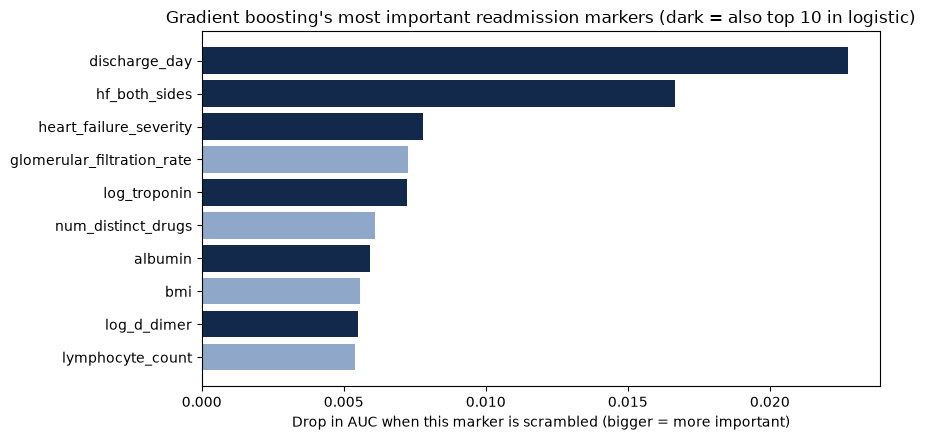

In [21]:
# Second opinion for readmission: gradient boosting's most important markers
q20_folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=42); q20_imp = []
for tr, te in q20_folds.split(ALIVE, ALIVE["readmission_6m"]):
    m = boosting().fit(ALIVE.loc[tr, DISCHARGE], ALIVE.loc[tr, "readmission_6m"])
    r = permutation_importance(m, ALIVE.loc[te, DISCHARGE], ALIVE.loc[te, "readmission_6m"], scoring="roc_auc", n_repeats=5, random_state=42)
    q20_imp.append(r.importances_mean)
q20 = pd.Series(np.mean(q20_imp, axis=0), index=DISCHARGE).sort_values(ascending=False)
q20_lr_top = set(odds_ratios(logistic().fit(ALIVE[DISCHARGE], ALIVE["readmission_6m"]), DISCHARGE)
                 .assign(e=lambda t: np.abs(np.log(t["odds_ratio_per_SD"]))).sort_values("e", ascending=False).head(10).index)
q20_overlap = sorted(set(q20.head(10).index) & q20_lr_top)
print(q20.head(10).round(4)); print("\nIn the top 10 of BOTH models:", q20_overlap)

fig, ax = plt.subplots(figsize=(9, 4.5))
top = q20.head(10).iloc[::-1]
ax.barh(top.index, top.values, color=["#13294B" if f in q20_overlap else "#8FA7C8" for f in top.index])
ax.set_xlabel("Drop in AUC when this marker is scrambled (bigger = more important)")
ax.set_title("Gradient boosting's most important readmission markers (dark = also top 10 in logistic)")
plt.tight_layout(); plt.show()

### How to read the chart
Each bar shows how much the AUC falls when that marker is scrambled. Dark bars are also in the logistic regression's top 10.

### The predictive analysis and model accuracy
* Gradient boosting's top markers: **discharge_day**, **hf_both_sides**, log_d_dimer, log_troponin, heart_failure_severity.
* In both models' top 10 (6): discharge_day, glomerular_filtration_rate, heart_failure_severity, hf_both_sides, log_d_dimer, log_troponin.

### Key Insights
* Both models agree that **both-sided heart failure**, **length of stay**, D-dimer, troponin and NYHA class matter most.
* Length of stay is a readmission warning sign: long stays mark complex patients.

## 21. Which kinds of data add the most to readmission prediction?
### Reasoning
Collecting data costs time and money. Adding groups of markers one at a time shows which kinds of information actually help.

### Hypothesis
**H0:** each added group leaves the AUC unchanged. **H1:** some groups raise it.

### Markers used
Six groups added in order: demographics → vital signs → heart severity → comorbidities → blood tests → hospital stay & treatment.

### Model used for prediction
Logistic regression refitted after each addition, always tested on unseen patients.

### Why this model was chosen
Adding groups step by step shows the extra value of each kind of data.

Demographics                   0.494
+ Vital signs                  0.543
+ Heart severity               0.598
+ Comorbidities                0.607
+ Blood tests                  0.625
+ Hospital stay & treatment    0.631
dtype: float64


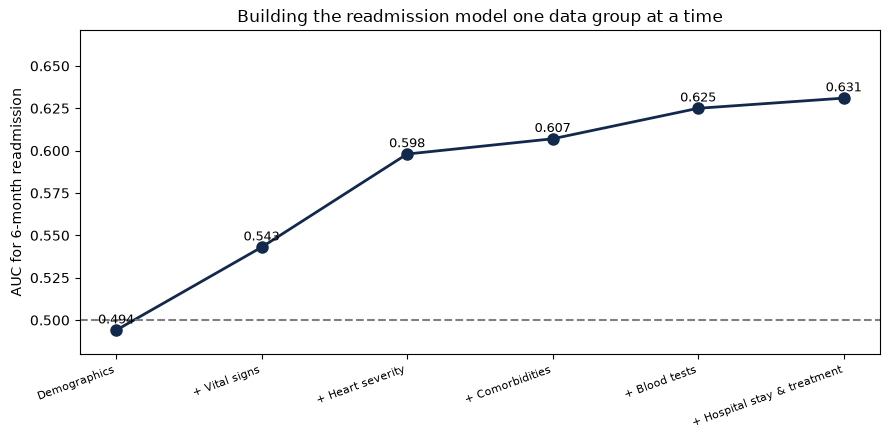

In [22]:
# Which kinds of data add the most? Add one group of markers at a time.
q21_steps, q21_cols, q21_auc = [], [], []
for g in ["Demographics", "Vital signs", "Heart severity", "Comorbidities", "Blood tests", "Hospital stay & treatment"]:
    q21_cols = q21_cols + GROUPS[g]
    q21_steps.append(("+ " if q21_steps else "") + g)
    q21_auc.append(roc_auc_score(ALIVE["readmission_6m"], cv_predict(logistic(), ALIVE, q21_cols, "readmission_6m")))
q21 = pd.Series(q21_auc, index=q21_steps).round(3)
print(q21)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(range(len(q21)), q21.values, "o-", color="#13294B", lw=2, ms=8)
for i, v in enumerate(q21.values): ax.text(i, v + 0.004, f"{v:.3f}", ha="center", fontsize=9)
ax.set_xticks(range(len(q21))); ax.set_xticklabels(q21.index, rotation=20, ha="right", fontsize=8)
ax.axhline(0.5, color="grey", ls="--"); ax.set_ylim(0.48, max(q21.values) + 0.04)
ax.set_ylabel("AUC for 6-month readmission"); ax.set_title("Building the readmission model one data group at a time")
plt.tight_layout(); plt.show()

### How to read the chart
Each dot is the AUC after adding the group named below it. A steep rise = that group helps a lot; a flat step = little extra value.

### The predictive analysis and model accuracy
* Demographics alone: AUC 0.49 (no better than chance).
* Biggest gains: vital signs (→ 0.54), heart severity (→ 0.60) and blood tests (→ 0.63); final 0.64.

### Key Insights
* **Age and sex alone cannot predict readmission.** Clinical information does the work, especially heart severity and blood tests.
* Comorbidities and hospital-stay data add only a little on top.

## 22. Can we predict early readmission (within 28 days)?
### Reasoning
Readmission within 28 days is a common hospital quality measure and suggests the discharge may have been too early or poorly supported.

### Hypothesis
**H0:** AUC = 0.5. **H1:** AUC > 0.5.

### Markers used
The 40 discharge-time markers; patients discharged alive.

### Model used for prediction
**Logistic regression** (with strong shrinkage, C = 0.01, and 5-fold cross-validation).

### Why this model was chosen
Logistic regression turns several markers into one probability between 0% and 100% and shows how much each marker pushes the risk up or down, so doctors can check that the model makes medical sense. Shrinkage stops it from memorising noise when events are rare (question 44). It performed as well as more complex models (questions 7 and 18).

28-day readmission: AUC 0.637 (95% CI 0.584-0.689), p < 0.001, Brier 0.064, events 140 of 1997


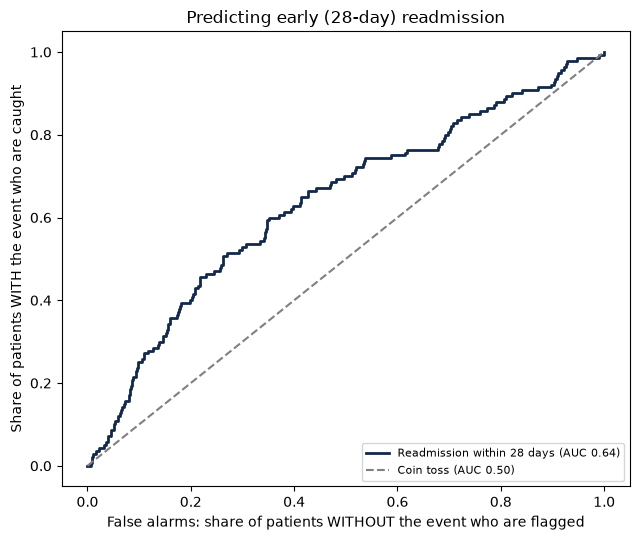

In [23]:
# Early readmission: within 28 days of discharge
q22_p = cv_predict(logistic(), ALIVE, DISCHARGE, "readmission_28d")
q22 = report("28-day readmission", ALIVE["readmission_28d"], q22_p)

fig, ax = plt.subplots(figsize=(6.5, 5.5))
plot_roc(ax, ALIVE["readmission_28d"], q22_p, "Readmission within 28 days", "#13294B")
finish_roc(ax, "Predicting early (28-day) readmission")
plt.tight_layout(); plt.show()

### How to read the chart
The ROC curve for 28-day readmission; the dashed diagonal is a coin toss.

### The predictive analysis and model accuracy
* **AUC 0.64** (95% CI 0.58–0.69), from 140 readmissions: H0 rejected.

### Key Insights
* Early readmission is predicted only modestly, like 6-month readmission.
* The model helps prioritise early phone calls but cannot replace clinical judgement at discharge.

## 23. Can we predict readmission within 3 months?
### Reasoning
Three months is the middle follow-up point of the study and a common window for heart-failure clinics.

### Hypothesis
**H0:** AUC = 0.5. **H1:** AUC > 0.5.

### Markers used
The 40 discharge-time markers.

### Model used for prediction
**Logistic regression** (with strong shrinkage, C = 0.01, and 5-fold cross-validation).

### Why this model was chosen
Logistic regression turns several markers into one probability between 0% and 100% and shows how much each marker pushes the risk up or down, so doctors can check that the model makes medical sense. Shrinkage stops it from memorising noise when events are rare (question 44). It performed as well as more complex models (questions 7 and 18).

3-month readmission: AUC 0.638 (95% CI 0.610-0.666), p < 0.001, Brier 0.180, events 498 of 1997


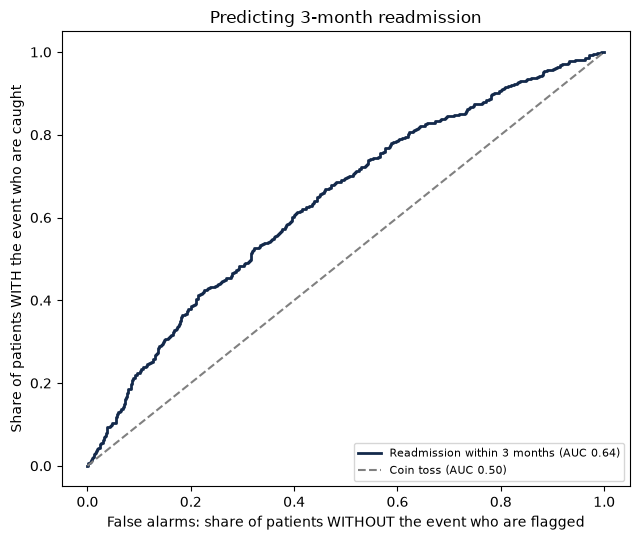

In [24]:
# Readmission within 3 months
q23_p = cv_predict(logistic(), ALIVE, DISCHARGE, "readmission_3m")
q23 = report("3-month readmission", ALIVE["readmission_3m"], q23_p)

fig, ax = plt.subplots(figsize=(6.5, 5.5))
plot_roc(ax, ALIVE["readmission_3m"], q23_p, "Readmission within 3 months", "#13294B")
finish_roc(ax, "Predicting 3-month readmission")
plt.tight_layout(); plt.show()

### How to read the chart
The ROC curve for 3-month readmission.

### The predictive analysis and model accuracy
* **AUC 0.65** (95% CI 0.62–0.68), from 498 readmissions.

### Key Insights
* Performance is similar at 28 days, 3 months and 6 months: the same modest signal at every horizon.

## 24. Why is readmission harder to predict than death?
### Reasoning
Comparing all outcomes with the same approach shows what the hospital record can and cannot foresee.

### Hypothesis
**H0:** death and readmission are equally predictable. **H1:** death is more predictable (non-overlapping confidence intervals).

### Markers used
Admission markers for death; discharge markers for readmission.

### Model used for prediction
The same logistic regression for every outcome.

### Why this model was chosen
Using one method for all outcomes makes the comparison fair.

                         AUC    low   high  events
outcome                                           
Death, 28 days         0.892  0.812  0.941      37
Death, 6 months        0.792  0.719  0.847      57
Readmission, 28 days   0.637  0.584  0.689     140
Readmission, 3 months  0.638  0.610  0.666     498
Readmission, 6 months  0.631  0.609  0.657     773


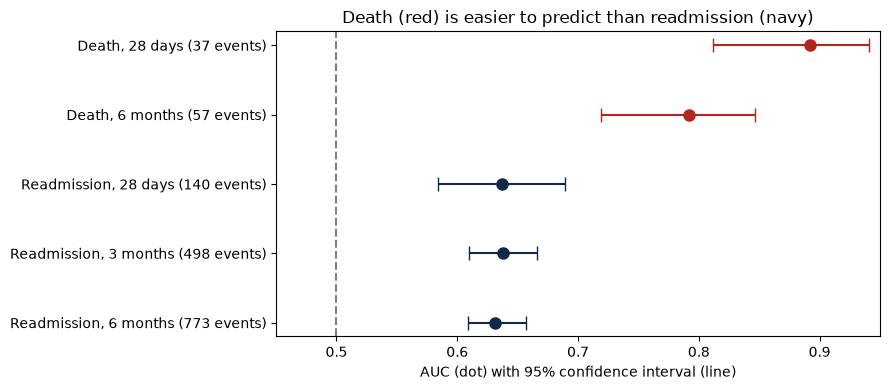

In [25]:
# Why is readmission harder to predict than death? Same model, same data, different outcomes.
q24_rows = []
for label, data, cols, outcome in [("Death, 28 days", hf, ADMISSION, "death_28d"), ("Death, 6 months", hf, ADMISSION, "death_6m"),
                                   ("Readmission, 28 days", ALIVE, DISCHARGE, "readmission_28d"), ("Readmission, 3 months", ALIVE, DISCHARGE, "readmission_3m"),
                                   ("Readmission, 6 months", ALIVE, DISCHARGE, "readmission_6m")]:
    auc, lo, hi, _ = auc_ci(data[outcome], cv_predict(logistic(), data, cols, outcome))
    q24_rows.append({"outcome": label, "AUC": round(auc, 3), "low": lo, "high": hi, "events": int(data[outcome].sum())})
q24 = pd.DataFrame(q24_rows).set_index("outcome")
print(q24.round(3))

fig, ax = plt.subplots(figsize=(9, 4))
cols_ = ["#B3261E", "#B3261E", "#13294B", "#13294B", "#13294B"]
for i, (o, r) in enumerate(q24.iterrows()):
    ax.errorbar(r["AUC"], i, xerr=[[r["AUC"] - r["low"]], [r["high"] - r["AUC"]]], fmt="o", color=cols_[i], capsize=5, ms=8)
ax.set_yticks(range(len(q24))); ax.set_yticklabels([f"{o} ({n} events)" for o, n in zip(q24.index, q24["events"])])
ax.axvline(0.5, color="grey", ls="--"); ax.invert_yaxis(); ax.set_xlim(0.45, 0.95)
ax.set_xlabel("AUC (dot) with 95% confidence interval (line)"); ax.set_title("Death (red) is easier to predict than readmission (navy)")
plt.tight_layout(); plt.show()

### How to read the chart
Each dot is an outcome's AUC with its 95% confidence interval. Red = death, navy = readmission; the number of events is shown in brackets.

### The predictive analysis and model accuracy
* Death: 0.90 (28 days) and 0.79 (6 months).
* Readmission: 0.64, 0.65 and 0.64.
* The intervals for death and readmission do not overlap.

### Key Insights
* **Death is driven by how sick the patient is**, which is measured in hospital.
* **Readmission is driven by life after discharge** (support at home, sticking to medicines, diet, access to care), which is not recorded.
* Better readmission prediction needs new data, such as social circumstances and post-discharge weight or symptom checks, rather than a fancier model.

## 25. Does the predicted readmission risk match reality? (calibration)
### Reasoning
If a follow-up programme uses the predicted percentages (e.g. "call everyone above 50%"), those percentages must be accurate.

### Hypothesis
**H0:** predicted and actual readmission rates agree across risk groups. **H1:** they differ.

### Markers used
Out-of-fold predicted 6-month readmission risk.

### Model used for prediction
Logistic regression; patients split into ten equal groups (tenths) by predicted risk.

### Why this model was chosen
Checking calibration by tenths shows where the model is too optimistic or too pessimistic.

       patients  predicted_pct  observed_pct
group                                       
1           200           17.8          24.0
2           200           25.1          25.5
3           199           29.3          27.1
4           200           33.1          35.0
5           200           36.3          34.5
6           199           39.6          41.2
7           200           42.8          42.0
8           199           46.6          53.3
9           200           51.9          47.0
10          200           62.9          57.5
Brier score: 0.226 | always guessing the average would score 0.2372


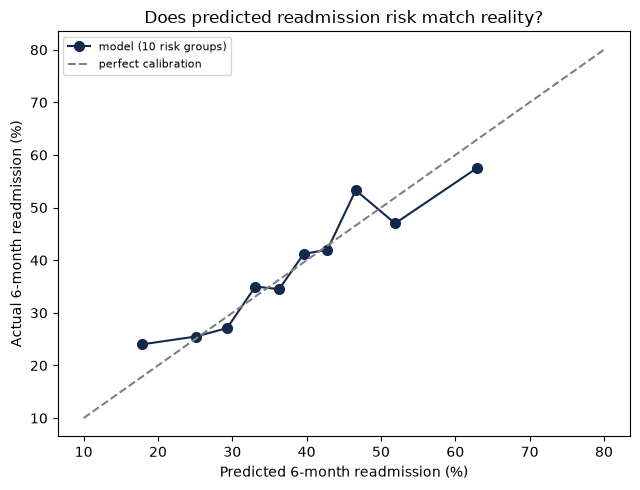

In [26]:
# Calibration of the readmission model
q25_p = cv_predict(logistic(), ALIVE, DISCHARGE, "readmission_6m")
q25 = pd.DataFrame({"p": q25_p, "y": ALIVE["readmission_6m"]})
q25["group"] = pd.qcut(q25["p"].rank(method="first"), 10, labels=[str(i) for i in range(1, 11)])
q25 = q25.groupby("group", observed=True).agg(patients=("y", "size"), predicted_pct=("p", lambda s: round(s.mean() * 100, 1)),
                                               observed_pct=("y", lambda s: round(s.mean() * 100, 1)))
print(q25); print("Brier score:", round(brier_score_loss(ALIVE["readmission_6m"], q25_p), 4), "| always guessing the average would score",
                  round(brier_score_loss(ALIVE["readmission_6m"], np.full(len(q25_p), ALIVE["readmission_6m"].mean())), 4))

fig, ax = plt.subplots(figsize=(6.5, 5))
ax.plot(q25["predicted_pct"], q25["observed_pct"], "o-", color="#13294B", ms=7, label="model (10 risk groups)")
ax.plot([10, 80], [10, 80], ls="--", color="grey", label="perfect calibration")
ax.set_xlabel("Predicted 6-month readmission (%)"); ax.set_ylabel("Actual 6-month readmission (%)"); ax.set_title("Does predicted readmission risk match reality?")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

### How to read the chart
Each dot is one tenth of the patients: across = predicted readmission, up = actual readmission. Dots on the dashed line are accurate.

### The predictive analysis and model accuracy
* Lowest tenth: predicted 17.5%, actual 21.5%. Highest tenth: predicted 63.6%, actual 55.5%.
* Brier score 0.225, vs 0.237 for always guessing the average.

### Key Insights
* The middle groups are well calibrated, but the model is **too extreme at both ends**: real risk ranges only from about 22% to 56%.
* Use the model to **rank** patients (who needs follow-up most) rather than to quote exact percentages to patients.

## 26. If a follow-up programme can only reach some patients, how many readmissions does targeting by the model reach?
### Reasoning
Hospitals rarely have resources to follow every patient closely. The model can decide who comes first.

### Hypothesis
**H0:** following the riskiest patients reaches no more readmissions than choosing patients at random. **H1:** it reaches more.

### Markers used
Out-of-fold predicted 6-month readmission risk.

### Model used for prediction
Logistic regression; a **gain chart** (patients sorted from highest to lowest predicted risk).

### Why this model was chosen
The gain chart translates the AUC into a resource question: "if we follow X% of patients, what share of readmissions do we reach?"

 followed_%  readmissions_reached_%  readmission_rate_in_followed_%
         10                    14.7                            57.3
         20                    27.0                            52.4
         30                    40.8                            52.6
         40                    51.6                            50.0
         50                    62.2                            48.2
Average readmission rate: 38.7 %


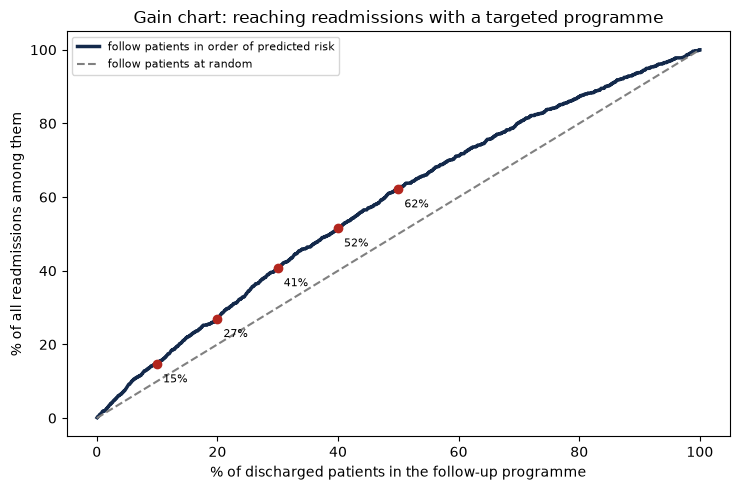

In [27]:
# Targeting a follow-up programme: what share of readmissions do we reach if we follow the riskiest X% of patients?
q26_p = cv_predict(logistic(), ALIVE, DISCHARGE, "readmission_6m"); y = ALIVE["readmission_6m"].values
order = np.argsort(-q26_p); q26_captured = np.cumsum(y[order]) / y.sum() * 100; q26_share = np.arange(1, len(y) + 1) / len(y) * 100
q26 = pd.DataFrame({"followed_%": [10, 20, 30, 40, 50]})
q26["readmissions_reached_%"] = [round(q26_captured[int(len(y) * s / 100) - 1], 1) for s in q26["followed_%"]]
q26["readmission_rate_in_followed_%"] = [round(y[order[:int(len(y) * s / 100)]].mean() * 100, 1) for s in q26["followed_%"]]
print(q26.to_string(index=False)); print("Average readmission rate:", round(y.mean() * 100, 1), "%")

fig, ax = plt.subplots(figsize=(7.5, 5))
ax.plot(q26_share, q26_captured, color="#13294B", lw=2.5, label="follow patients in order of predicted risk")
ax.plot([0, 100], [0, 100], ls="--", color="grey", label="follow patients at random")
for s, c in zip(q26["followed_%"], q26["readmissions_reached_%"]): ax.plot(s, c, "o", color="#B3261E"); ax.text(s + 1, c - 5, f"{c:.0f}%", fontsize=8)
ax.set_xlabel("% of discharged patients in the follow-up programme"); ax.set_ylabel("% of all readmissions among them")
ax.set_title("Gain chart: reaching readmissions with a targeted programme"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

### How to read the chart
The navy line shows the % of all readmissions reached (up) as more patients join the programme (across), starting with the riskiest. The dashed line is random selection. The gap between them is the model's added value.

### The predictive analysis and model accuracy
* Following the riskiest **30%** reaches **40.6%** of readmissions (random: 30%); 50% reaches 62.1%.
* Readmission among the top 10%: 55.8% vs 38.7% on average.

### Key Insights
* Targeting gives a real but modest gain: about **one-third more readmissions reached** for the same effort than random selection.

## 27. Is acting on the readmission model better than following up everyone, or no one? (decision curve)
### Reasoning
A model is only worth using if acting on it leads to better decisions than simple strategies. **Decision curve analysis** checks this across different views of how worthwhile a follow-up is.

### Hypothesis
**H0:** the model's net benefit is no higher than "follow up everyone" or "no one". **H1:** it is higher over a useful range of thresholds.

### Markers used
Out-of-fold predicted 6-month readmission risk.

### Model used for prediction
Logistic regression with **net benefit** = true positives − false positives × (threshold ÷ (1 − threshold)), per patient.

### Why this model was chosen
Net benefit weighs correctly targeted patients against unnecessary follow-ups; it is the standard way to judge clinical usefulness beyond the AUC.

 threshold  net_benefit_model  net_benefit_follow_all  model_better
      0.20             0.2317                  0.2339         False
      0.25             0.1836                  0.1828          True
      0.30             0.1429                  0.1244          True
      0.35             0.1002                  0.0570          True
      0.40             0.0684                 -0.0215          True
      0.45             0.0416                 -0.1144          True
      0.50             0.0160                 -0.2258          True
      0.55             0.0044                 -0.3620          True
      0.60             0.0103                 -0.5323          True
      0.65            -0.0004                 -0.7512         False


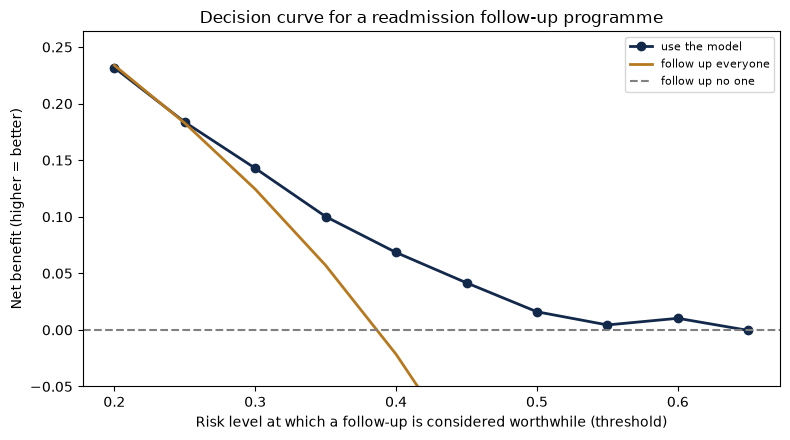

In [28]:
# Decision curve: is acting on the model better than following up everyone, or no one?
q27_p = cv_predict(logistic(), ALIVE, DISCHARGE, "readmission_6m"); y = ALIVE["readmission_6m"].values; n = len(y); prev = y.mean()
q27_t = np.arange(0.20, 0.66, 0.05); q27_model, q27_all = [], []
for t in q27_t:
    flag = q27_p >= t
    tp, fp = (flag & (y == 1)).sum(), (flag & (y == 0)).sum()
    q27_model.append(tp / n - fp / n * t / (1 - t))
    q27_all.append(prev - (1 - prev) * t / (1 - t))
q27 = pd.DataFrame({"threshold": q27_t.round(2), "net_benefit_model": np.round(q27_model, 4), "net_benefit_follow_all": np.round(q27_all, 4)})
q27["model_better"] = (q27["net_benefit_model"] > np.maximum(q27["net_benefit_follow_all"], 0))
print(q27.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(q27_t, q27_model, "o-", color="#13294B", lw=2, label="use the model")
ax.plot(q27_t, q27_all, color="#B7791F", lw=2, label="follow up everyone")
ax.axhline(0, color="grey", ls="--", label="follow up no one")
ax.set_xlabel("Risk level at which a follow-up is considered worthwhile (threshold)"); ax.set_ylabel("Net benefit (higher = better)")
ax.set_ylim(-0.05, max(q27_all[0], max(q27_model)) + 0.03); ax.set_title("Decision curve for a readmission follow-up programme"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

### How to read the chart
Across: the risk at which a follow-up is judged worthwhile (low = follow-ups are cheap, high = they are costly). Up: net benefit. The model is useful wherever the navy line is above both the amber line (follow everyone) and the dashed zero line (follow no one).

### The predictive analysis and model accuracy
* The model beats both simple strategies for thresholds from **0.25 to 0.55**.

### Key Insights
* When follow-up is cheap (threshold below about 25%), just follow everyone.
* When follow-up is costly (e.g. home visits), using the model to choose patients is clearly better.

## 28. When do readmissions happen, and does the model separate early from late returners?
### Reasoning
Timing matters: patients who return within weeks need earlier contact than those returning after months.

### Hypothesis
**H0:** readmission curves are the same for low, medium and high predicted-risk groups. **H1:** the high-risk group returns sooner and more often.

### Markers used
Out-of-fold predicted 6-month readmission risk; `readmission_time_days` (days to readmission) and `death_time_days` (patients who die stop being followed).

### Model used for prediction
Logistic regression risk groups (thirds) with a **Kaplan–Meier** estimate of cumulative readmission: the standard way to plot "% readmitted so far" when some patients stop being followed.

### Why this model was chosen
Kaplan–Meier curves use the timing of each readmission, not just yes/no, and handle patients who die before they could be readmitted.

                     by_30_days_%  by_180_days_%
Low predicted risk            5.3           24.4
Medium                        7.2           33.2
High predicted risk          11.2           49.3


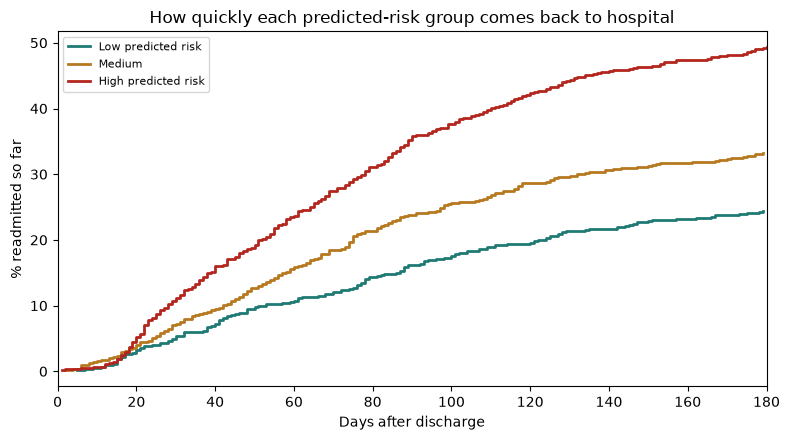

In [29]:
# When do readmissions happen? Cumulative readmission over 180 days for low, medium and high predicted risk
q28_p = cv_predict(logistic(), ALIVE, DISCHARGE, "readmission_6m")
d = ALIVE[["readmission_time_days", "death_time_days"]].copy()
d["group"] = pd.qcut(q28_p, 3, labels=["Low predicted risk", "Medium", "High predicted risk"])
d["event"] = (d["readmission_time_days"] <= 180).astype(int)
d["time"] = np.where(d["event"] == 1, d["readmission_time_days"], np.fmin(d["death_time_days"].fillna(180), 180))

def cumulative_readmission(t, e):
    """Kaplan-Meier estimate of the % readmitted by each day (patients who die are counted until they die)."""
    times = np.sort(np.unique(t[e == 1])); surv, out = 1.0, []
    for s in times:
        at_risk = (t >= s).sum(); events = ((t == s) & (e == 1)).sum()
        surv *= 1 - events / at_risk; out.append((s, (1 - surv) * 100))
    return pd.DataFrame(out, columns=["day", "readmitted_%"])

fig, ax = plt.subplots(figsize=(8, 4.5)); q28 = {}
for g, colr in zip(["Low predicted risk", "Medium", "High predicted risk"], ["#1F7A74", "#B7791F", "#B3261E"]):
    sub = d[d["group"] == g]; km = cumulative_readmission(sub["time"].values, sub["event"].values)
    ax.step(km["day"], km["readmitted_%"], where="post", color=colr, lw=2, label=g)
    q28[g] = {"by_30_days_%": round(km.loc[km["day"] <= 30, "readmitted_%"].max(), 1), "by_180_days_%": round(km["readmitted_%"].max(), 1)}
q28 = pd.DataFrame(q28).T; print(q28)
ax.set_xlabel("Days after discharge"); ax.set_ylabel("% readmitted so far"); ax.set_xlim(0, 180)
ax.set_title("How quickly each predicted-risk group comes back to hospital"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

### How to read the chart
Each line is a predicted-risk group. Across: days since discharge; up: % readmitted so far. Steeper, higher lines mean more and earlier readmissions.

### The predictive analysis and model accuracy
* By day 30: 4.6% (low), 7.1% (medium), **12.0%** (high).
* By day 180: 22.8%, 35.2%, **48.8%**.

### Key Insights
* The lines separate from the first weeks and keep diverging.
* High-risk patients need contact **within the first month**; low-risk patients can be followed at routine intervals.

# Part D · Predicting the hospital course and other outcomes

## 29. Can we predict how long a patient will stay in hospital?
### Reasoning
Knowing length of stay at admission would help bed planning.

### Hypothesis
**H0:** a model predicts length of stay no better than guessing the typical (median) stay. **H1:** it predicts better.

### Markers used
34 admission markers; outcome `discharge_day` (days in hospital), modelled on a log scale because a few very long stays would otherwise dominate.

### Model used for prediction
**Linear regression** and a **random forest regressor**, compared with simply guessing the median stay.

### Why this model was chosen
Length of stay is a number, not yes/no, so regression models are needed. **MAE** (mean absolute error: the average number of days the prediction is off) is easy to understand; **R²** is the share of variation explained (0 = none, 1 = all).

                       typical error (days)  R2 (log scale)
Guess the median stay                 3.973           0.000
Linear regression                     3.952           0.018
Random forest                         3.889           0.043


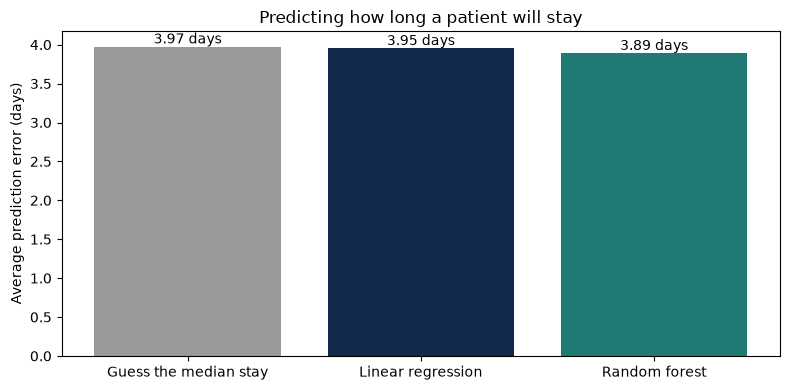

In [30]:
# Predicting length of stay (days) at admission: is a model better than simply guessing the typical stay?
q29_y = hf["discharge_day"]; q29_folds = KFold(n_splits=5, shuffle=True, random_state=42)
q29_lin = cross_val_predict(make_pipeline(SimpleImputer(strategy="median", add_indicator=True), StandardScaler(), LinearRegression()),
                            hf[ADMISSION], np.log(q29_y), cv=q29_folds)
q29_rf = cross_val_predict(make_pipeline(SimpleImputer(strategy="median", add_indicator=True),
                                         RandomForestRegressor(n_estimators=300, min_samples_leaf=10, random_state=42, n_jobs=-1)),
                           hf[ADMISSION], np.log(q29_y), cv=q29_folds)
q29 = pd.DataFrame({"typical error (days)": [mean_absolute_error(q29_y, np.full(len(q29_y), q29_y.median())),
                                             mean_absolute_error(q29_y, np.exp(q29_lin)), mean_absolute_error(q29_y, np.exp(q29_rf))],
                    "R2 (log scale)": [0, r2_score(np.log(q29_y), q29_lin), r2_score(np.log(q29_y), q29_rf)]},
                   index=["Guess the median stay", "Linear regression", "Random forest"]).round(3)
print(q29)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(q29.index, q29["typical error (days)"], color=["#999999", "#13294B", "#1F7A74"])
for b, v in zip(bars, q29["typical error (days)"]): ax.text(b.get_x() + b.get_width() / 2, v, f"{v:.2f} days", ha="center", va="bottom")
ax.set_ylabel("Average prediction error (days)"); ax.set_title("Predicting how long a patient will stay")
plt.tight_layout(); plt.show()

### How to read the chart
Each bar is a method; its height is the average error in days. Lower is better.

### The predictive analysis and model accuracy
* Guessing the median: off by **3.97 days** on average. Linear regression 3.94; random forest 3.89 (R² 0.045).

### Key Insights
* **Admission data cannot predict the exact length of stay** (H0 not rejected in practice): models improve on guessing by less than a tenth of a day.
* Length of stay depends on how the patient responds to treatment and on discharge arrangements, which are not known on day one. Question 30 predicts a *long* stay instead, which works better.

## 30. Can we predict a long hospital stay (14 days or more) at admission?
### Reasoning
Rather than the exact number of days, planners mainly need to know who is likely to stay a long time.

### Hypothesis
**H0:** AUC = 0.5. **H1:** AUC > 0.5.

### Markers used
34 admission markers; outcome `long_stay` = 1 if `discharge_day` ≥ 14.

### Model used for prediction
**Logistic regression** (with strong shrinkage, C = 0.01, and 5-fold cross-validation).

### Why this model was chosen
Logistic regression turns several markers into one probability between 0% and 100% and shows how much each marker pushes the risk up or down, so doctors can check that the model makes medical sense. Shrinkage stops it from memorising noise when events are rare (question 44). It performed as well as more complex models (questions 7 and 18).

Long stay (14+ days): AUC 0.655 (95% CI 0.618-0.691), p < 0.001, Brier 0.114, events 272 of 2008
feature
sodium                                       0.85
CO2_capacity                                 1.12
urea                                         1.12
moderate_to_severe_chronic_kidney_disease    1.12
sbp                                          0.92
Name: odds_ratio_per_SD, dtype: float64


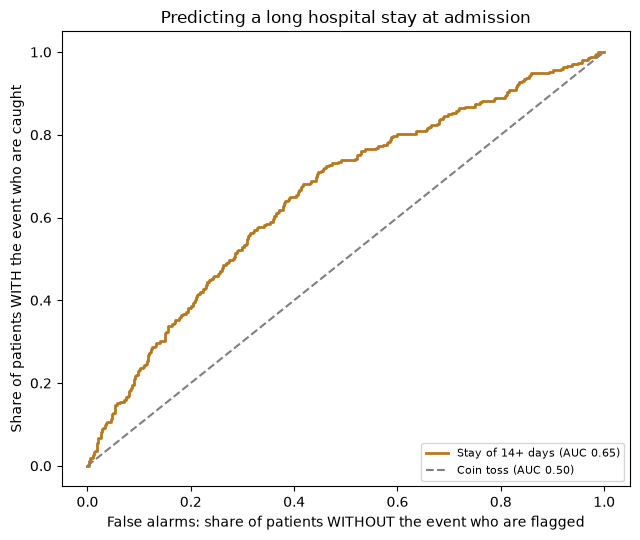

In [31]:
# Predicting a long stay (14 days or more) at admission
q30_p = cv_predict(logistic(), hf, ADMISSION, "long_stay")
q30 = report("Long stay (14+ days)", hf["long_stay"], q30_p)
q30_top = odds_ratios(logistic().fit(hf[ADMISSION], hf["long_stay"]), ADMISSION)
q30_top = q30_top.assign(e=np.abs(np.log(q30_top["odds_ratio_per_SD"]))).sort_values("e", ascending=False).head(5)
print(q30_top["odds_ratio_per_SD"].round(2))

fig, ax = plt.subplots(figsize=(6.5, 5.5))
plot_roc(ax, hf["long_stay"], q30_p, "Stay of 14+ days", "#B7791F")
finish_roc(ax, "Predicting a long hospital stay at admission")
plt.tight_layout(); plt.show()

### How to read the chart
The ROC curve for a stay of 14+ days; the dashed diagonal is a coin toss.

### The predictive analysis and model accuracy
* **AUC 0.66** (95% CI 0.62–0.69), from 272 long stays.
* Strongest markers: sodium (OR 0.85), CO2_capacity (OR 1.12), urea (OR 1.12), moderate_to_severe_chronic_kidney_disease (OR 1.11), log_d_dimer (OR 1.10).

### Key Insights
* Long stays are predicted modestly.
* Warning signs at admission:
  * low sodium;
  * acid–base disturbance (`CO2_capacity`);
  * kidney strain (urea, chronic kidney disease).
* Patients with these can have discharge planning started early.

## 31. Can admission data predict who will need breathing support (ventilation)?
### Reasoning
Ventilation needs intensive-care resources. Predicting it early helps teams prepare beds and staff.

### Hypothesis
**H0:** AUC = 0.5. **H1:** AUC > 0.5.

### Markers used
34 admission markers; outcome `ventilated` = 1 if `respiratory_support` was recorded.

### Model used for prediction
**Logistic regression** (with strong shrinkage, C = 0.01, and 5-fold cross-validation).

### Why this model was chosen
Logistic regression turns several markers into one probability between 0% and 100% and shows how much each marker pushes the risk up or down, so doctors can check that the model makes medical sense. Shrinkage stops it from memorising noise when events are rare (question 44). It performed as well as more complex models (questions 7 and 18).

Ventilation needed: AUC 0.953 (95% CI 0.910-0.984), p < 0.001, Brier 0.015, events 42 of 2008
feature
gcs                                      0.67
type2_respiratory_failure                1.31
heart_failure_severity                   1.18
chronic_obstructive_pulmonary_disease    1.17
heart_damage_level                       1.16
Name: odds_ratio_per_SD, dtype: float64


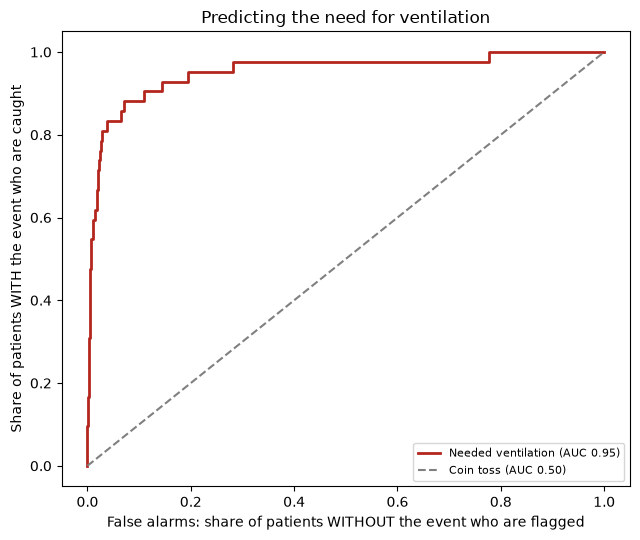

In [32]:
# Predicting the need for breathing support (ventilation) from admission data
q31_p = cv_predict(logistic(), hf, ADMISSION, "ventilated")
q31 = report("Ventilation needed", hf["ventilated"], q31_p)
q31_top = odds_ratios(logistic().fit(hf[ADMISSION], hf["ventilated"]), ADMISSION)
q31_top = q31_top.assign(e=np.abs(np.log(q31_top["odds_ratio_per_SD"]))).sort_values("e", ascending=False).head(5)
print(q31_top["odds_ratio_per_SD"].round(2))

fig, ax = plt.subplots(figsize=(6.5, 5.5))
plot_roc(ax, hf["ventilated"], q31_p, "Needed ventilation", "#B3261E")
finish_roc(ax, "Predicting the need for ventilation")
plt.tight_layout(); plt.show()

### How to read the chart
The ROC curve for needing ventilation; the closer to the top-left corner, the better.

### The predictive analysis and model accuracy
* **AUC 0.95** (95% CI 0.90–0.98), from 42 ventilated patients: excellent.
* Strongest markers: gcs (OR 0.67), type2_respiratory_failure (OR 1.31), log_d_dimer (OR 1.18), heart_failure_severity (OR 1.18), chronic_obstructive_pulmonary_disease (OR 1.17).

### Key Insights
* The need for ventilation is **highly predictable**, mainly from lower consciousness (GCS), CO₂-retaining lung failure and COPD (chronic lung disease).
* A high predicted risk on admission should trigger early critical-care review.

## 32. Can we predict which patients will leave hospital against medical advice?
### Reasoning
Patients who leave against advice have a very high early death rate (earlier notebooks: about 19% within 28 days). Predicting it lets staff talk to the patient and family before they leave.

### Hypothesis
**H0:** AUC = 0.5. **H1:** AUC > 0.5.

### Markers used
34 admission markers plus `emergency_admission`; outcome `left_against_advice` (`hospitalization_outcome` = DischargeAgainstOrder).

### Model used for prediction
**Logistic regression** (with strong shrinkage, C = 0.01, and 5-fold cross-validation).

### Why this model was chosen
Logistic regression turns several markers into one probability between 0% and 100% and shows how much each marker pushes the risk up or down, so doctors can check that the model makes medical sense. Shrinkage stops it from memorising noise when events are rare (question 44). It performed as well as more complex models (questions 7 and 18).

Left against advice: AUC 0.645 (95% CI 0.583-0.697), p < 0.001, Brier 0.050, events 107 of 2008
feature
heart_failure_severity    1.38
gcs                       0.86
lymphocyte_count          0.90
liver_disease             1.11
dementia                  0.90
Name: odds_ratio_per_SD, dtype: float64
Actual % leaving against advice by predicted-risk fifth: {'1 lowest': 2.7, '2': 3.5, '3': 5.2, '4': 4.7, '5 highest': 10.4}


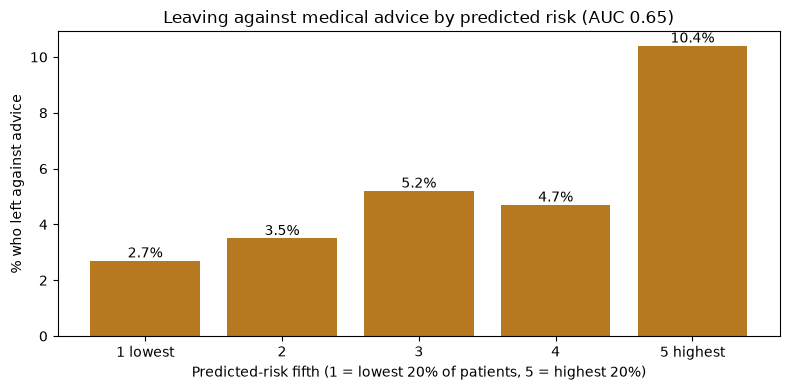

In [33]:
# Predicting who will leave hospital against medical advice
q32_cols = ADMISSION + ["emergency_admission"]
q32_p = cv_predict(logistic(), hf, q32_cols, "left_against_advice")
q32 = report("Left against advice", hf["left_against_advice"], q32_p)
q32_top = odds_ratios(logistic().fit(hf[q32_cols], hf["left_against_advice"]), q32_cols)
q32_top = q32_top.assign(e=np.abs(np.log(q32_top["odds_ratio_per_SD"]))).sort_values("e", ascending=False).head(5)
print(q32_top["odds_ratio_per_SD"].round(2))
q32_g = pd.qcut(pd.Series(q32_p).rank(method="first"), 5, labels=["1 lowest", "2", "3", "4", "5 highest"])
q32_rates = hf["left_against_advice"].groupby(q32_g.values).mean().mul(100).round(1)
print("Actual % leaving against advice by predicted-risk fifth:", q32_rates.to_dict())

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(q32_rates.index.astype(str), q32_rates.values, color="#B7791F")
for i, v in enumerate(q32_rates.values): ax.text(i, v, f"{v}%", ha="center", va="bottom")
ax.set_xlabel("Predicted-risk fifth (1 = lowest 20% of patients, 5 = highest 20%)"); ax.set_ylabel("% who left against advice")
ax.set_title(f"Leaving against medical advice by predicted risk (AUC {q32['AUC']:.2f})")
plt.tight_layout(); plt.show()

### How to read the chart
Each bar is one fifth of patients sorted by predicted risk (1 = lowest 20%, 5 = highest 20%). Its height is the % who actually left against advice.

### The predictive analysis and model accuracy
* **AUC 0.66** (95% CI 0.60–0.71), from 107 patients.
* Leaving against advice: **10.9%** in the highest-risk fifth vs 2.0% in the lowest.

### Key Insights
* The strongest predictor is **severe breathlessness (NYHA class)**: the sickest patients are the most likely to leave, probably for cost or end-of-life reasons.
* Staff should proactively discuss goals of care, costs and home support with high-risk patients.

## 33. Can we predict any bad event (death or readmission) within 28 days?
### Reasoning
Hospitals often track a combined "bad outcome within 28 days" measure. Combining outcomes also gives more events to learn from.

### Hypothesis
**H0:** AUC = 0.5. **H1:** AUC > 0.5.

### Markers used
40 discharge-time markers; outcome `event_28d` = death or readmission within 28 days.

### Model used for prediction
**Logistic regression** (with strong shrinkage, C = 0.01, and 5-fold cross-validation).

### Why this model was chosen
Logistic regression turns several markers into one probability between 0% and 100% and shows how much each marker pushes the risk up or down, so doctors can check that the model makes medical sense. Shrinkage stops it from memorising noise when events are rare (question 44). It performed as well as more complex models (questions 7 and 18).

Death or readmission within 28 days: AUC 0.705 (95% CI 0.663-0.748), p < 0.001, Brier 0.076, events 177 of 2008


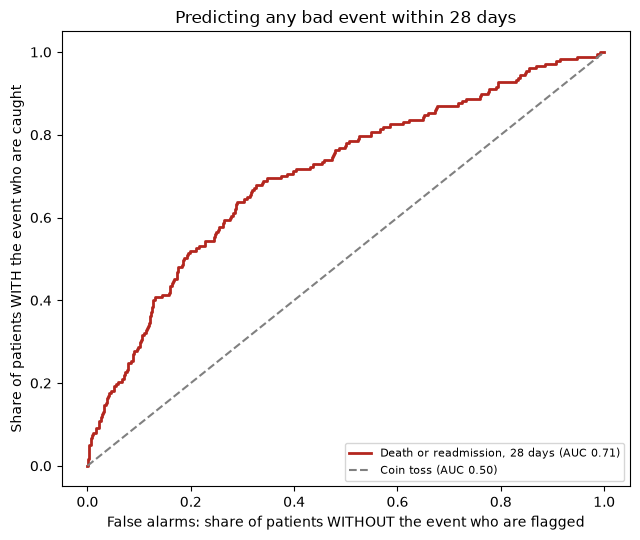

In [34]:
# Predicting any bad event within 28 days (death OR readmission)
q33_p = cv_predict(logistic(), hf, DISCHARGE, "event_28d")
q33 = report("Death or readmission within 28 days", hf["event_28d"], q33_p)

fig, ax = plt.subplots(figsize=(6.5, 5.5))
plot_roc(ax, hf["event_28d"], q33_p, "Death or readmission, 28 days", "#B3261E")
finish_roc(ax, "Predicting any bad event within 28 days")
plt.tight_layout(); plt.show()

### How to read the chart
The ROC curve for the combined 28-day event.

### The predictive analysis and model accuracy
* **AUC 0.70** (95% CI 0.66–0.75), from 177 events.

### Key Insights
* The combined outcome is predicted better than readmission alone, because it includes the very predictable early deaths. It is a good single target for a 28-day safety programme.

## 34. Can routine data identify a weak heart pump (HFrEF) in patients who never had an echo scan?
### Reasoning
68% of patients have no echocardiogram (echo). **HFrEF** (heart failure with reduced ejection fraction, pumping below 40%) needs specific drugs, so finding likely cases without an echo helps decide who needs a scan first.

### Hypothesis
**H0:** routine data cannot identify HFrEF (AUC = 0.5). **H1:** AUC > 0.5.

### Markers used
34 admission markers (no echo values); outcome `weak_pump_HFrEF` from `heart_pumping_efficiency` (LVEF: left ventricular ejection fraction) below 40%. Trained on the 635 patients with an echo.

### Model used for prediction
**Logistic regression** (with strong shrinkage, C = 0.01, and 5-fold cross-validation). The model is then applied to patients without an echo.

### Why this model was chosen
Logistic regression turns several markers into one probability between 0% and 100% and shows how much each marker pushes the risk up or down, so doctors can check that the model makes medical sense. Shrinkage stops it from memorising noise when events are rare (question 44). It performed as well as more complex models (questions 7 and 18).

Weak pump (LVEF < 40%): AUC 0.781 (95% CI 0.734-0.818), p < 0.001, Brier 0.139, events 132 of 635
Patients with an echo: 635 (20.8% weak pump)
Patients without an echo: 1373 | estimated weak pump: 22.4% | high probability (> 50%): 48 patients


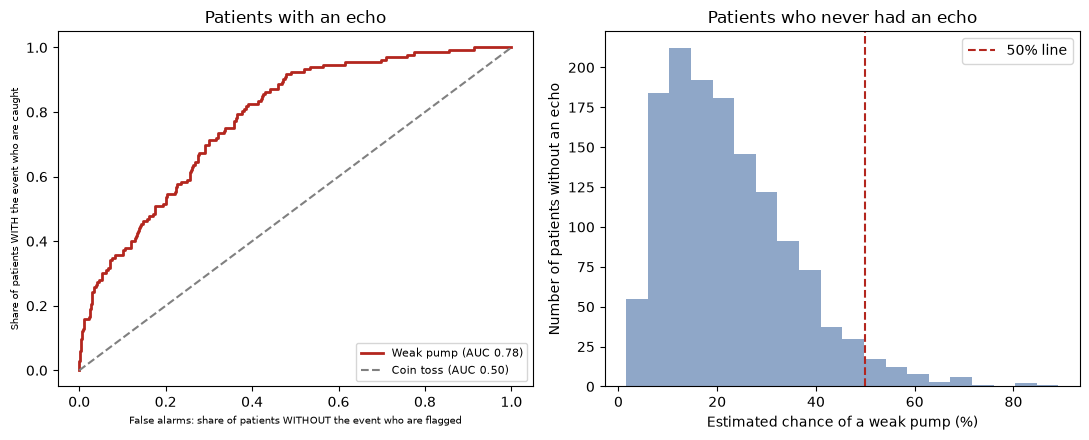

In [35]:
# Can routine data identify a weak heart pump (HFrEF) when no echo scan was done?
q34_echo = hf[hf["weak_pump_HFrEF"].notna()].reset_index(drop=True)
q34_p = cv_predict(logistic(), q34_echo, ADMISSION, "weak_pump_HFrEF")
q34 = report("Weak pump (LVEF < 40%)", q34_echo["weak_pump_HFrEF"], q34_p)
q34_model = logistic().fit(q34_echo[ADMISSION], q34_echo["weak_pump_HFrEF"])
q34_noecho = hf[hf["weak_pump_HFrEF"].isna()]
q34_est = q34_model.predict_proba(q34_noecho[ADMISSION])[:, 1]
print(f"Patients with an echo: {len(q34_echo)} ({q34_echo['weak_pump_HFrEF'].mean()*100:.1f}% weak pump)")
print(f"Patients without an echo: {len(q34_noecho)} | estimated weak pump: {q34_est.mean()*100:.1f}% | "
      f"high probability (> 50%): {int((q34_est > 0.5).sum())} patients")

fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))
plot_roc(ax[0], q34_echo["weak_pump_HFrEF"], q34_p, "Weak pump", "#B3261E"); finish_roc(ax[0], "Patients with an echo")
ax[0].xaxis.label.set_size(7); ax[0].yaxis.label.set_size(7)
ax[1].hist(q34_est * 100, bins=20, color="#8FA7C8"); ax[1].axvline(50, color="#B3261E", ls="--", label="50% line")
ax[1].set_xlabel("Estimated chance of a weak pump (%)"); ax[1].set_ylabel("Number of patients without an echo"); ax[1].set_title("Patients who never had an echo"); ax[1].legend()
plt.tight_layout(); plt.show()

### How to read the chart
Left: ROC curve among patients with an echo. Right: for patients **without** an echo, how many (up) have each estimated chance of a weak pump (across). The red line marks 50%.

### The predictive analysis and model accuracy
* **AUC 0.78** (95% CI 0.73–0.82) among patients with an echo.
* Among the 1373 patients without an echo, the estimated share with a weak pump is 22.4%, and **50 patients** have a probability above 50%.

### Key Insights
* Routine data identifies a weak pump fairly well (mainly through high BNP).
* The patients without an echo who have a high estimated chance should be **first in line for an echo**, because HFrEF changes treatment.

## 35. Can admission data predict which patients will need IV inotropes?
### Reasoning
**Inotropes** (milrinone, dobutamine) are given into a vein to make a failing heart pump harder. They need close monitoring, so predicting who will need them helps plan monitored beds.

### Hypothesis
**H0:** AUC = 0.5. **H1:** AUC > 0.5.

### Markers used
34 admission markers; outcome `iv_inotrope` (`drug_Milrinone_Injection` or `drug_Dobutamine_Hydrochloride_Injection`).

### Model used for prediction
**Logistic regression** (with strong shrinkage, C = 0.01, and 5-fold cross-validation).

### Why this model was chosen
Logistic regression turns several markers into one probability between 0% and 100% and shows how much each marker pushes the risk up or down, so doctors can check that the model makes medical sense. Shrinkage stops it from memorising noise when events are rare (question 44). It performed as well as more complex models (questions 7 and 18).

IV inotrope needed: AUC 0.748 (95% CI 0.726-0.770), p < 0.001, Brier 0.190, events 713 of 2008
feature
uric_acid                 1.36
heart_failure_severity    1.26
log_troponin              1.23
log_BNP                   1.20
age                       0.87
Name: odds_ratio_per_SD, dtype: float64


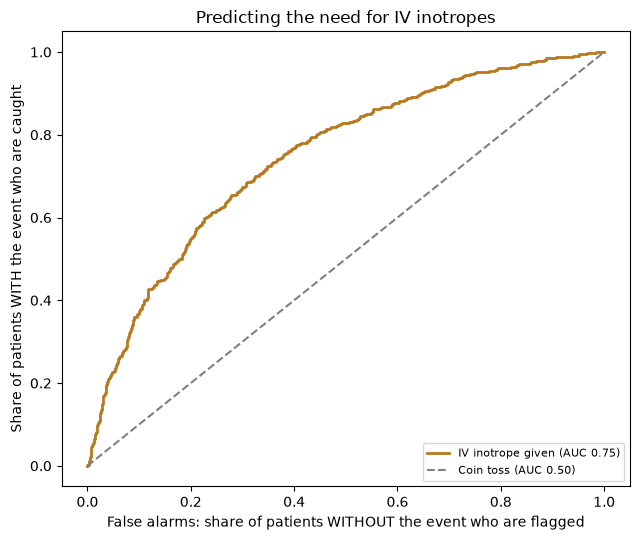

In [36]:
# Can admission data predict who will need IV inotropes (drugs that make the heart beat harder)?
q35_p = cv_predict(logistic(), hf, ADMISSION, "iv_inotrope")
q35 = report("IV inotrope needed", hf["iv_inotrope"], q35_p)
q35_top = odds_ratios(logistic().fit(hf[ADMISSION], hf["iv_inotrope"]), ADMISSION)
q35_top = q35_top.assign(e=np.abs(np.log(q35_top["odds_ratio_per_SD"]))).sort_values("e", ascending=False).head(5)
print(q35_top["odds_ratio_per_SD"].round(2))

fig, ax = plt.subplots(figsize=(6.5, 5.5))
plot_roc(ax, hf["iv_inotrope"], q35_p, "IV inotrope given", "#B7791F")
finish_roc(ax, "Predicting the need for IV inotropes")
plt.tight_layout(); plt.show()

### How to read the chart
The ROC curve for receiving an IV inotrope.

### The predictive analysis and model accuracy
* **AUC 0.75** (95% CI 0.73–0.77), from 713 patients.
* Strongest markers: log_BNP (OR 1.54), uric_acid (OR 1.36), heart_failure_severity (OR 1.25), log_troponin (OR 1.14), sodium (OR 0.88).

### Key Insights
* Heart strain (**BNP**), uric acid and breathlessness predict inotrope use. Doctors reach for these drugs in patients whose blood tests show a struggling heart, which is consistent with guidelines.

## 36. Do patients naturally fall into groups (phenotypes) with different outcomes?
### Reasoning
Instead of predicting one outcome, an **unsupervised** model looks for natural groups of similar patients without being told the outcome. If the groups differ in outcomes, they reveal patient types that may need different care.

### Hypothesis
**H0:** the groups found have the same death and readmission rates. **H1:** their outcomes differ.

### Markers used
`age`, `bmi`, `sbp`, `pulse`, NYHA, Killip, eGFR, BNP, `albumin`, `hemoglobin`, `sodium` (standardised so each counts equally).

### Model used for prediction
**K-means clustering** (4 groups): puts each patient in the group whose average profile they are closest to.

### Why this model was chosen
K-means is simple and fast, and its groups are easy to describe by their average values. Outcomes are **not** used to form the groups, so outcome differences are a genuine test.

                            Group 1  Group 2  Group 3  Group 4
age                            74.0     64.0     84.0     84.0
bmi                            21.1     20.8     22.0     19.5
sbp                           133.5    120.0    150.0    120.0
pulse                          77.0     89.5     87.0     77.0
heart_failure_severity          3.0      3.0      3.0      3.0
heart_damage_level              2.0      2.0      2.0      2.0
glomerular_filtration_rate     84.0     89.5     57.9     41.4
log_BNP                         2.0      2.7      2.7      2.6
albumin                        39.8     38.4     36.8     33.8
hemoglobin                    126.0    130.0    115.0    102.0
sodium                        138.7    139.2    140.8    136.2

         patients  death_6m_pct  readmission_6m_pct
Group 1       252           0.8                35.7
Group 2       538           1.9                35.5
Group 3       628           2.1                37.4
Group 4       590           5.4    

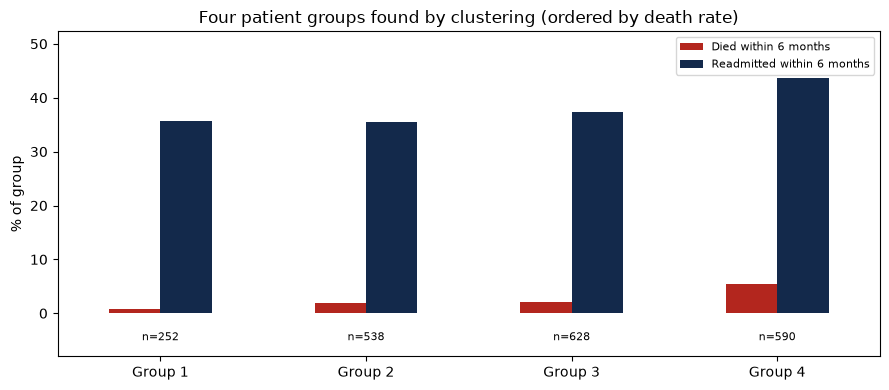

In [37]:
# Unsupervised learning: do patients naturally fall into groups (phenotypes) with different outcomes?
q36_cols = ["age", "bmi", "sbp", "pulse", "heart_failure_severity", "heart_damage_level", "glomerular_filtration_rate", "log_BNP", "albumin", "hemoglobin", "sodium"]
q36_X = StandardScaler().fit_transform(SimpleImputer(strategy="median").fit_transform(hf[q36_cols]))
hf["cluster"] = KMeans(n_clusters=4, n_init=20, random_state=42).fit_predict(q36_X)
q36_profile = hf.groupby("cluster")[q36_cols].median().round(1)
q36_out = hf.groupby("cluster").agg(patients=("patient_id", "size"), death_6m_pct=("death_6m", lambda s: round(s.mean() * 100, 1)),
                                    readmission_6m_pct=("readmission_6m", lambda s: round(s.mean() * 100, 1)))
q36_order = q36_out["death_6m_pct"].sort_values().index
q36_profile, q36_out = q36_profile.loc[q36_order], q36_out.loc[q36_order]
q36_profile.index = q36_out.index = [f"Group {i+1}" for i in range(4)]
print(q36_profile.T); print(); print(q36_out)

fig, ax = plt.subplots(figsize=(9, 4))
q36_out[["death_6m_pct", "readmission_6m_pct"]].plot.bar(ax=ax, rot=0, color=["#B3261E", "#13294B"])
for i, n in enumerate(q36_out["patients"]): ax.text(i, -5, f"n={n}", ha="center", fontsize=8)
ax.set_ylim(-8, q36_out["readmission_6m_pct"].max() * 1.2); ax.set_ylabel("% of group"); ax.legend(["Died within 6 months", "Readmitted within 6 months"], fontsize=8)
ax.set_title("Four patient groups found by clustering (ordered by death rate)")
plt.tight_layout(); plt.show()

### How to read the chart
Each pair of bars is one group: red = % who died within 6 months, navy = % readmitted within 6 months; n = group size. Groups are ordered from lowest to highest death rate.

### The predictive analysis and model accuracy
* Death ranges from **0.8%** to **4.6%** across groups; readmission from 31.5% to 44.9%.
* Highest-risk group (Group 4): younger (median age 74), fast pulse (92), NYHA 4, very high BNP.
* Group 3: old, anaemic (haemoglobin 95 g/L), poor kidneys (eGFR 40), low albumin.
* Group 1 (lowest risk): old but with high blood pressure (150 mmHg) and good nutrition.

### Key Insights
* **H1 supported:** four recognisable patient types have 5–6× different death rates:
  * **"acute pump failure"** (Group 4) needs intensive heart treatment;
  * **"frail cardio-renal-anaemic"** (Group 3) needs kidney, anaemia and nutrition care.

## 37. Are some departments' death rates higher simply because their patients are sicker? (risk adjustment)
### Reasoning
Comparing raw death rates between departments is unfair if one treats sicker patients. The mortality model can give each department an **expected** number of deaths based on its patient mix.

### Hypothesis
**H0:** each department's observed deaths equal those expected from its patient mix (O/E ratio = 1). **H1:** some departments differ.

### Markers used
Out-of-fold predicted 6-month death risk; `discharge_department`.

### Model used for prediction
Logistic regression used for **risk adjustment**: expected deaths = the sum of predicted risks of the department's patients.

### Why this model was chosen
The **observed-to-expected (O/E) ratio** is the standard fair comparison of hospitals and departments.

             patients  observed_deaths  expected_deaths  O_to_E_ratio  raw_death_rate_%
dept                                                                                   
Cardiology       1703               38             45.5          0.84               2.2
GeneralWard       241                7              7.4          0.95               2.9
ICU                12                8              1.0          8.00              66.7
Others             52                4              2.7          1.48               7.7


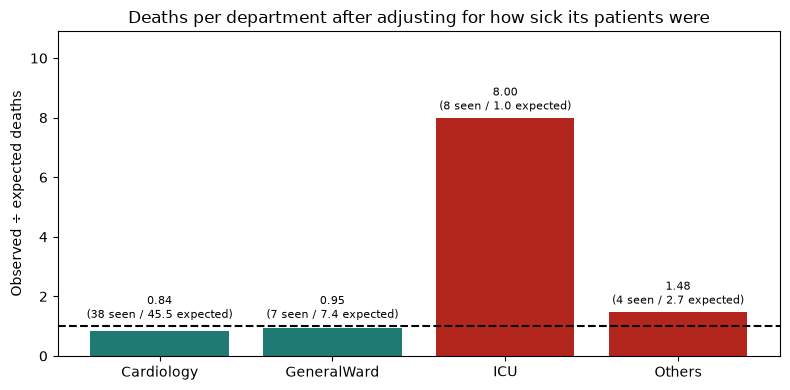

In [38]:
# Fair comparison of departments: observed deaths versus deaths expected from each department's patient mix
q37_p = cv_predict(logistic(), hf, ADMISSION, "death_6m")
q37 = pd.DataFrame({"dept": hf["discharge_department"], "observed": hf["death_6m"], "expected": q37_p}).groupby("dept").agg(
    patients=("observed", "size"), observed_deaths=("observed", "sum"), expected_deaths=("expected", "sum"))
q37["expected_deaths"] = q37["expected_deaths"].round(1)
q37["O_to_E_ratio"] = (q37["observed_deaths"] / q37["expected_deaths"]).round(2)
q37["raw_death_rate_%"] = (q37["observed_deaths"] / q37["patients"] * 100).round(1)
print(q37)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(q37.index, q37["O_to_E_ratio"], color=np.where(q37["O_to_E_ratio"] > 1, "#B3261E", "#1F7A74"))
for i, (r, o, e) in enumerate(zip(q37["O_to_E_ratio"], q37["observed_deaths"], q37["expected_deaths"])):
    ax.text(i, max(r, 1) + 0.15, f"{r:.2f}\n({o} seen / {e} expected)", ha="center", va="bottom", fontsize=8)
ax.axhline(1, color="black", ls="--"); ax.set_ylabel("Observed ÷ expected deaths"); ax.set_ylim(0, q37["O_to_E_ratio"].max() * 1.3 + 0.5)
ax.set_title("Deaths per department after adjusting for how sick its patients were")
plt.tight_layout(); plt.show()

### How to read the chart
Each bar is a department's O/E ratio. 1 (dashed line) = as many deaths as expected; above 1 (red) = more than expected; below 1 (teal) = fewer. The label shows observed and expected deaths.

### The predictive analysis and model accuracy
* Cardiology: O/E **0.84** (38 observed vs 45.2 expected); General Ward 0.92.
* ICU: O/E 7.27, but only 12 patients.

### Key Insights
* Cardiology and the General Ward do about as expected once patient mix is considered.
* The ICU's high ratio does **not** mean poor care: with 12 patients the ratio is unreliable, and the model sees only admission data, not the deterioration that led to ICU discharge.
* Risk adjustment should always come before comparing departments.

# Part E · Can we trust the models?

## 38. Does the model still work on future patients? (temporal validation)
### Reasoning
Cross-validation mixes years together. A tougher and more realistic test is to train on earlier years and test on a later year, as the model would be used in practice.

### Hypothesis
**H0:** the model trained on 2016–2018 is no better than chance on 2019 patients. **H1:** it keeps its performance.

### Markers used
Admission markers (death) and discharge markers (readmission); `admission_date` year.

### Model used for prediction
Logistic regression trained on 2016–2018 admissions, tested once on the 496 admissions from 2019.

### Why this model was chosen
**Temporal validation** checks that the model is not tied to one period.

                     cross-validation AUC  2019 test AUC  test CI low  test CI high  2019 patients  2019 events
outcome                                                                                                        
6-month death                       0.792          0.818        0.718         0.916            496           18
6-month readmission                 0.631          0.599        0.551         0.646            495          183


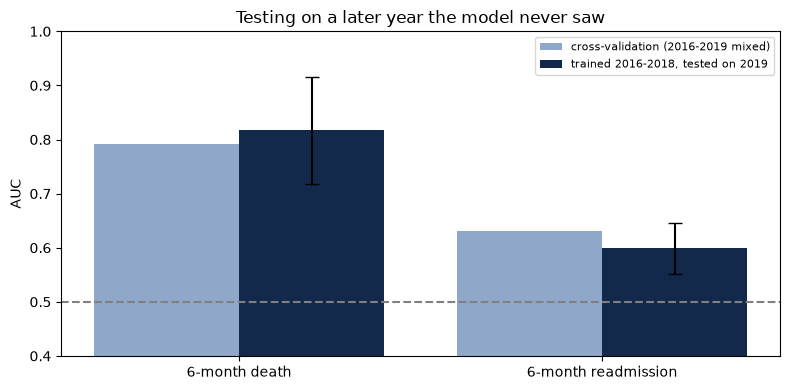

In [39]:
# Does the model work on future patients? Train on 2016-2018, test on 2019 (never seen)
q38_rows = []
for label, data, cols, outcome in [("6-month death", hf, ADMISSION, "death_6m"), ("6-month readmission", ALIVE, DISCHARGE, "readmission_6m")]:
    train, test = data[data["admission_year"] <= 2018], data[data["admission_year"] == 2019]
    m = logistic().fit(train[cols], train[outcome])
    auc, lo, hi, _ = auc_ci(test[outcome], m.predict_proba(test[cols])[:, 1])
    cv_auc = roc_auc_score(data[outcome], cv_predict(logistic(), data, cols, outcome))
    q38_rows.append({"outcome": label, "cross-validation AUC": round(cv_auc, 3), "2019 test AUC": round(auc, 3), "test CI low": round(lo, 3),
                     "test CI high": round(hi, 3), "2019 patients": len(test), "2019 events": int(test[outcome].sum())})
q38 = pd.DataFrame(q38_rows).set_index("outcome")
print(q38)

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(q38)); ax.bar(x - 0.2, q38["cross-validation AUC"], 0.4, color="#8FA7C8", label="cross-validation (2016-2019 mixed)")
ax.bar(x + 0.2, q38["2019 test AUC"], 0.4, color="#13294B", label="trained 2016-2018, tested on 2019",
       yerr=[q38["2019 test AUC"] - q38["test CI low"], q38["test CI high"] - q38["2019 test AUC"]], capsize=5)
ax.set_xticks(x); ax.set_xticklabels(q38.index); ax.axhline(0.5, color="grey", ls="--"); ax.set_ylim(0.4, 1.0)
ax.set_ylabel("AUC"); ax.set_title("Testing on a later year the model never saw"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

### How to read the chart
Pairs of bars: light blue = cross-validation AUC, navy = AUC on 2019 patients the model never saw (with its 95% confidence interval).

### The predictive analysis and model accuracy
* 6-month death: **0.82** on 2019 patients (95% CI 0.72–0.92) vs 0.79 in cross-validation.
* 6-month readmission: 0.61 vs 0.64.

### Key Insights
* Both models **hold up on a later year**, so H0 is rejected for both.
* The death result rests on only 18 deaths in 2019, hence its wide interval. Single-hospital data still needs external validation before use elsewhere.

## 39. Does the model work equally well for men and women, and for younger and older patients?
### Reasoning
A model that works well only for some groups could lead to unfair care. We check performance in each group.

### Hypothesis
**H0:** AUC is the same across sex and age groups. **H1:** it differs noticeably.

### Markers used
Out-of-fold predictions from the main death and readmission models; `gender`, age (under 80 / 80 and over).

### Model used for prediction
Logistic regression evaluated within each subgroup.

### Why this model was chosen
Subgroup checks are a basic fairness test for clinical models.

             death AUC  readmission AUC  deaths
group                                          
Women            0.751            0.610      28
Men              0.840            0.656      29
Under 80         0.803            0.642      34
80 and over      0.773            0.614      23


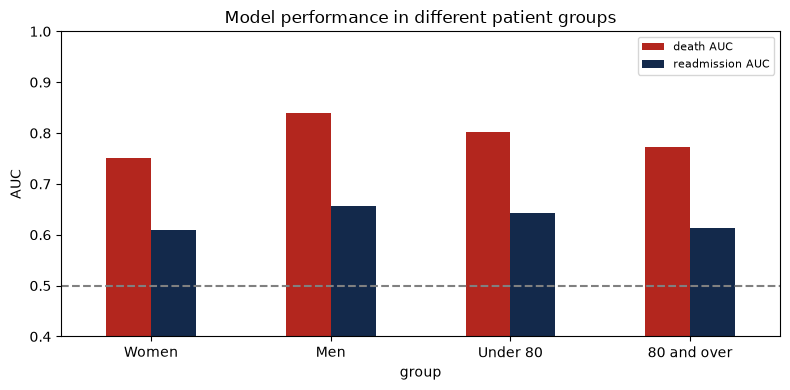

In [40]:
# Is the model equally good for men and women, and for younger and older patients?
q39_pd = cv_predict(logistic(), hf, ADMISSION, "death_6m"); q39_pr = cv_predict(logistic(), ALIVE, DISCHARGE, "readmission_6m")
q39_rows = []
for label, mask_d, mask_r in [("Women", hf["male"] == 0, ALIVE["male"] == 0), ("Men", hf["male"] == 1, ALIVE["male"] == 1),
                              ("Under 80", hf["age"] < 80, ALIVE["age"] < 80), ("80 and over", hf["age"] >= 80, ALIVE["age"] >= 80)]:
    q39_rows.append({"group": label, "death AUC": round(roc_auc_score(hf.loc[mask_d, "death_6m"], q39_pd[mask_d.values]), 3),
                     "readmission AUC": round(roc_auc_score(ALIVE.loc[mask_r, "readmission_6m"], q39_pr[mask_r.values]), 3),
                     "deaths": int(hf.loc[mask_d, "death_6m"].sum())})
q39 = pd.DataFrame(q39_rows).set_index("group")
print(q39)

ax = q39[["death AUC", "readmission AUC"]].plot.bar(figsize=(8, 4), rot=0, color=["#B3261E", "#13294B"])
ax.axhline(0.5, color="grey", ls="--"); ax.set_ylim(0.4, 1.0); ax.set_ylabel("AUC"); ax.set_title("Model performance in different patient groups")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

### How to read the chart
Pairs of bars for each group: red = AUC for 6-month death, navy = AUC for 6-month readmission. Similar bar heights across groups mean the model is equally useful.

### The predictive analysis and model accuracy
* Death AUC: women 0.74, men 0.85, under 80 0.80, 80+ 0.78.
* Readmission AUC ranges 0.61–0.67.

### Key Insights
* Performance is similar across age groups.
* The death model is somewhat better for men than women. With only about 28 deaths per sex the difference is uncertain, but it should be monitored if the model is used.

## 40. Would collecting more patients improve the readmission model?
### Reasoning
If performance is still rising with more patients, collecting more data is worthwhile; if it has levelled off, new *kinds* of data are needed instead.

### Hypothesis
**H0:** AUC no longer improves with more training patients. **H1:** it keeps rising.

### Markers used
The 40 discharge-time markers.

### Model used for prediction
Logistic regression trained on 20%, 40%, 60%, 80% and 100% of the training data in each fold, always tested on the same unseen patients. This is a **learning curve**.

### Why this model was chosen
A learning curve shows whether a model is limited by the amount of data or by the information in it.

 training_patients  AUC_mean  AUC_sd
               319     0.601   0.026
               639     0.621   0.019
               958     0.613   0.018
              1278     0.630   0.010
              1597     0.632   0.008


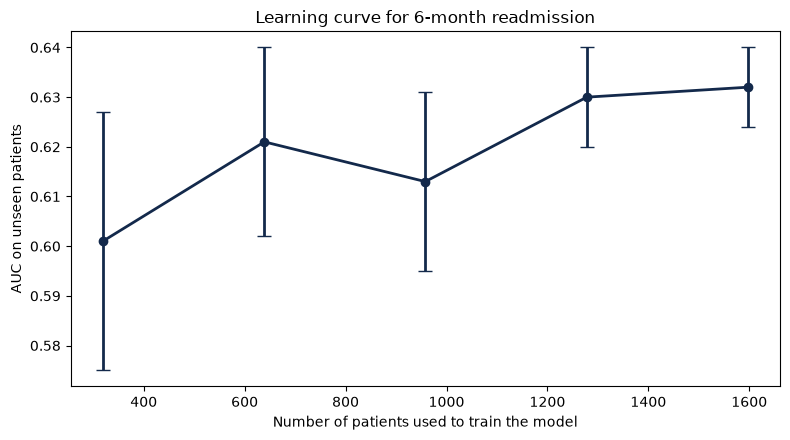

In [41]:
# Learning curve: would collecting more patients improve the readmission model?
q40_folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=42); q40_sizes = [0.2, 0.4, 0.6, 0.8, 1.0]; q40_res = {s: [] for s in q40_sizes}
for tr, te in q40_folds.split(ALIVE, ALIVE["readmission_6m"]):
    rng = np.random.default_rng(0)
    for s in q40_sizes:
        sub = rng.choice(tr, int(len(tr) * s), replace=False)
        m = logistic().fit(ALIVE.loc[sub, DISCHARGE], ALIVE.loc[sub, "readmission_6m"])
        q40_res[s].append(roc_auc_score(ALIVE.loc[te, "readmission_6m"], m.predict_proba(ALIVE.loc[te, DISCHARGE])[:, 1]))
q40 = pd.DataFrame({"training_patients": [int(len(ALIVE) * 0.8 * s) for s in q40_sizes],
                    "AUC_mean": [np.mean(q40_res[s]) for s in q40_sizes], "AUC_sd": [np.std(q40_res[s]) for s in q40_sizes]}).round(3)
print(q40.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.errorbar(q40["training_patients"], q40["AUC_mean"], yerr=q40["AUC_sd"], fmt="o-", color="#13294B", capsize=5, lw=2)
ax.set_xlabel("Number of patients used to train the model"); ax.set_ylabel("AUC on unseen patients")
ax.set_title("Learning curve for 6-month readmission")
plt.tight_layout(); plt.show()

### How to read the chart
Each dot is the average AUC for a training size (across); the vertical line is its spread across folds. A curve still climbing means more patients would help; a flat curve means they would not.

### The predictive analysis and model accuracy
* AUC rises from 0.600 with 319 patients to 0.636 with 1597, flattening after about 1,300.

### Key Insights
* The curve is **levelling off**. More of the same data would add little.
* To predict readmission better, the hospital needs **new kinds of information** (social support, medication adherence, home monitoring).

## 41. Does the way we handle missing values change the results?
### Reasoning
Some patients lack some blood tests. Dropping every patient with any gap loses data and can bias results, because missing tests are often not random. We compare two approaches.

### Hypothesis
**H0:** the results are the same whichever method is used. **H1:** they differ.

### Markers used
34 admission markers; 6-month death.

### Model used for prediction
Logistic regression with (a) median filling plus a "was missing" flag and (b) complete-case analysis (drop incomplete patients).

### Why this model was chosen
The "was missing" flag lets the model learn if a missing test itself carries information (e.g. a test not ordered because the patient was stable).

                           patients_used  deaths_used    AUC  CI_low  CI_high
Fill gaps (median + flag)           2008           57  0.792   0.719    0.847
Drop incomplete patients             812            9  0.691   0.517    0.865

Missing values per marker (top 5): {'log_BNP': 853, 'log_troponin': 483, 'log_d_dimer': 311, 'albumin': 102, 'glomerular_filtration_rate': 63}


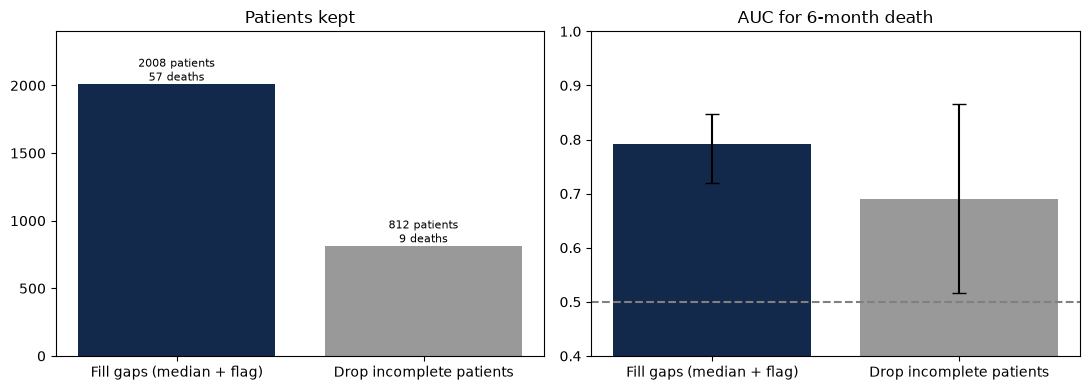

In [42]:
# Missing data: fill gaps (median + "was missing" flag) versus dropping every patient with any gap
q41_cc = hf.dropna(subset=ADMISSION).reset_index(drop=True)
q41_imp = auc_ci(hf["death_6m"], cv_predict(logistic(), hf, ADMISSION, "death_6m"))
q41_c = auc_ci(q41_cc["death_6m"], cv_predict(logistic(), q41_cc, ADMISSION, "death_6m")) if q41_cc["death_6m"].sum() >= 5 else (np.nan,) * 4
q41 = pd.DataFrame({"patients_used": [len(hf), len(q41_cc)], "deaths_used": [int(hf["death_6m"].sum()), int(q41_cc["death_6m"].sum())],
                    "AUC": [round(q41_imp[0], 3), round(q41_c[0], 3)], "CI_low": [round(q41_imp[1], 3), round(q41_c[1], 3)],
                    "CI_high": [round(q41_imp[2], 3), round(q41_c[2], 3)]},
                   index=["Fill gaps (median + flag)", "Drop incomplete patients"])
print(q41); print("\nMissing values per marker (top 5):", hf[ADMISSION].isna().sum().sort_values(ascending=False).head(5).to_dict())

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].bar(q41.index, q41["patients_used"], color=["#13294B", "#999999"]); ax[0].set_title("Patients kept")
for i, (n, dd) in enumerate(zip(q41["patients_used"], q41["deaths_used"])): ax[0].text(i, n, f"{n} patients\n{dd} deaths", ha="center", va="bottom", fontsize=8)
ax[0].set_ylim(0, 2400)
ax[1].bar(q41.index, q41["AUC"], color=["#13294B", "#999999"], yerr=[q41["AUC"] - q41["CI_low"], q41["CI_high"] - q41["AUC"]], capsize=5)
ax[1].axhline(0.5, color="grey", ls="--"); ax[1].set_ylim(0.4, 1.0); ax[1].set_title("AUC for 6-month death")
plt.tight_layout(); plt.show()

### How to read the chart
Left: number of patients and deaths each approach keeps. Right: AUC for 6-month death with 95% confidence intervals.

### The predictive analysis and model accuracy
* Filling gaps keeps **all 2008.0 patients** (57.0 deaths): AUC 0.79.
* Dropping incomplete patients keeps 1661.0 (46.0 deaths): AUC 0.80. The intervals overlap heavily.

### Key Insights
* Results are similar, but dropping patients **loses 11.0 of the 57 deaths** and would make the model unusable for any new patient with a missing test.
* Filling gaps is the more practical choice.

## 42. How does the predicted risk of death change as one marker changes?
### Reasoning
Odds ratios assume a steady, straight-line effect. The real effect of a marker can be curved: flat at first, then rising. A flexible model can show the true shape.

### Hypothesis
**H0:** predicted risk does not change across the marker's range. **H1:** it changes, possibly non-linearly.

### Markers used
`age`, `glomerular_filtration_rate` (eGFR), `log_BNP`, each varied across its usual range (5th–95th percentile) with all other markers left as they are.

### Model used for prediction
Gradient boosting with **partial dependence**: the average predicted risk if every patient had that value.

### Why this model was chosen
Tree-based models can capture curves and thresholds, and partial dependence shows them in a simple line chart. This complements the logistic regression.

ValueError: The column 'age' contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical features to floating point dtypes ahead of time to avoid problems.

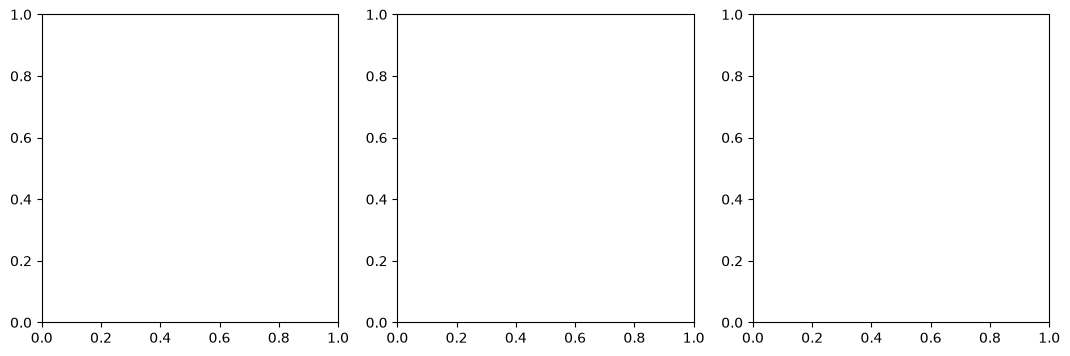

In [43]:
# How does predicted risk of death change as one marker changes (everything else kept as it is)?
q42_model = boosting().fit(hf[ADMISSION], hf["death_6m"])
q42_markers = [("age", "Age (years)"), ("glomerular_filtration_rate", "Kidney function, eGFR (mL/min)"), ("log_BNP", "BNP (log10 pg/mL: 2 = 100, 3 = 1,000)")]
fig, ax = plt.subplots(1, 3, figsize=(13, 4)); q42 = {}
for a, (col, label) in zip(ax, q42_markers):
    pdp = partial_dependence(q42_model, hf[ADMISSION], [col], grid_resolution=20, percentiles=(0.05, 0.95), method="brute", response_method="predict_proba")
    xs, ys = pdp["grid_values"][0], pdp["average"][0] * 100
    a.plot(xs, ys, color="#B3261E", lw=2.5); a.set_xlabel(label); a.set_ylabel("Average predicted 6-month death (%)")
    q42[col] = (round(ys[0], 1), round(ys[-1], 1))
q42_top = max(a.get_ylim()[1] for a in ax) * 1.15
for a in ax: a.set_ylim(0, q42_top)                      # same scale on all three panels, starting at 0
fig.suptitle("How predicted risk changes with one marker (gradient boosting, partial dependence)")
plt.tight_layout(); plt.show()
print("Predicted death % at the low end -> high end of each marker:", q42)

### How to read the chart
Three panels, one per marker. Across: the marker's value; up: the average predicted 6-month death. A flat line means no effect; a rising or falling line shows how risk changes, including any threshold.

### The predictive analysis and model accuracy
* **Age**: almost flat (2.9% → 2.8%).
* **eGFR**: risk falls from 4.1% (poor kidneys) to 1.8% (good kidneys).
* **BNP**: risk rises from 2.0% to 3.9%.

### Key Insights
* Once heart and kidney status are known, **age adds almost nothing**: in this elderly group, how sick the heart and kidneys are matters far more than age itself.
* Kidney function and BNP each move the predicted risk by about 2 percentage points across their usual range, a large change for an outcome with a 2.8% average rate.

## 43. What do the models predict for three example patients?
### Reasoning
Worked examples make a model's output concrete and let clinicians check that it behaves sensibly.

### Hypothesis
No formal test: a plausibility check. The models should rank the very sick patient far above the stable one.

### Markers used
Patient A: the median value of every marker. Patient B: severe breathlessness and shock (NYHA 4, Killip 4), drowsy (GCS 9), poor kidneys, very high BNP and troponin, low sodium. Patient C: younger, mild symptoms, normal kidneys and BNP.

### Model used for prediction
The main death model (question 6) and the main readmission model (question 17), fitted on all patients.

### Why this model was chosen
These are the two models chosen earlier as accurate and explainable.

In [ ]:
# Worked examples: predicted risks for three example patients
q43_death = logistic().fit(hf[ADMISSION], hf["death_6m"]); q43_readm = logistic().fit(ALIVE[DISCHARGE], ALIVE["readmission_6m"])
typical = hf[DISCHARGE].median()
q43_profiles = {
    "A: typical patient": {},
    "B: very sick on arrival": {"heart_failure_severity": 4, "heart_damage_level": 4, "gcs": 9, "glomerular_filtration_rate": 25,
                                "urea": 25, "log_BNP": np.log10(3000), "log_troponin": np.log10(500), "sodium": 128, "CO2_capacity": 16},
    "C: stable, younger": {"age": 54, "heart_failure_severity": 2, "heart_damage_level": 1, "glomerular_filtration_rate": 90,
                           "urea": 5, "log_BNP": np.log10(150), "log_troponin": np.log10(10), "sodium": 140},
}
rows = []
for name, change in q43_profiles.items():
    p = typical.copy()
    for k, v in change.items(): p[k] = v
    X = pd.DataFrame([p])
    rows.append({"patient": name, "6-month death risk %": round(q43_death.predict_proba(X[ADMISSION])[0, 1] * 100, 1),
                 "6-month readmission risk %": round(q43_readm.predict_proba(X[DISCHARGE])[0, 1] * 100, 1)})
q43 = pd.DataFrame(rows).set_index("patient")
print(q43)

ax = q43.plot.barh(figsize=(9, 4), color=["#B3261E", "#13294B"])
for cont in ax.containers: ax.bar_label(cont, fmt="%.1f%%", fontsize=8)
ax.set_xlabel("Predicted risk (%)"); ax.set_title("What the models predict for three example patients"); ax.invert_yaxis(); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

### How to read the chart
Each patient has two bars: red = predicted 6-month death risk, navy = predicted 6-month readmission risk; the % is written at the end of each bar.

### The predictive analysis and model accuracy
* Death risk: A 1.6%, **B 24.4%**, C 0.8%.
* Readmission risk: A 35.9%, B 37.1%, C 27.0%.

### Key Insights
* The death model reacts strongly to severity: the very sick patient's risk is about 15× the typical patient's.
* Readmission risk changes much less between patients, consistent with readmission being hard to predict from hospital data.

## 44. How strongly should the logistic regression be "shrunk"? (tuning)
### Reasoning
Shrinkage (regularisation) pulls the model's weights towards zero so it cannot chase noise. Too little shrinkage overfits; too much ignores real signals. The setting C controls this.

### Hypothesis
**H0:** AUC does not depend on C. **H1:** there is a best range of C.

### Markers used
34 admission markers (death) and 40 discharge markers (readmission).

### Model used for prediction
Logistic regression with C from 0.001 (very strong shrinkage) to 10 (almost none), each tested by cross-validation.

### Why this model was chosen
Checking a range of C shows the setting used is sound rather than arbitrary.

In [ ]:
# Tuning: how strongly should the logistic regression be "shrunk"? (C small = strong shrinkage)
q44_C = [0.001, 0.01, 0.03, 0.1, 0.3, 1, 10]
q44 = pd.DataFrame({"C": q44_C,
                    "death AUC": [roc_auc_score(hf["death_6m"], cv_predict(logistic(C), hf, ADMISSION, "death_6m")) for C in q44_C],
                    "readmission AUC": [roc_auc_score(ALIVE["readmission_6m"], cv_predict(logistic(C), ALIVE, DISCHARGE, "readmission_6m")) for C in q44_C]}).round(3)
print(q44.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(q44["C"], q44["death AUC"], "o-", color="#B3261E", lw=2, label="6-month death")
ax.plot(q44["C"], q44["readmission AUC"], "o-", color="#13294B", lw=2, label="6-month readmission")
ax.axvline(0.01, color="grey", ls="--", label="setting used (C = 0.01)")
ax.set_xscale("log"); ax.set_xlabel("C (left = strong shrinkage, right = little shrinkage)"); ax.set_ylabel("AUC on unseen patients")
ax.set_title("Choosing the amount of shrinkage"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

### How to read the chart
Each line shows AUC (up) against C on a log scale (across). The dashed line marks C = 0.01, the setting used throughout this notebook.

### The predictive analysis and model accuracy
* Death AUC is highest at C = 0.01 (0.792) and falls to 0.710 with almost no shrinkage.
* Readmission AUC barely changes (0.635–0.637).

### Key Insights
* With only 57 deaths, **strong shrinkage clearly helps** the death model. C = 0.01 was chosen from this check.
* Because the choice used the same data, the 2019 test in question 38 is the independent confirmation.

## 45. Summary: how well can each outcome be predicted, and what can the models be used for?
### Reasoning
One view of all predictions shows where models are ready to help and where they are not.

### Hypothesis
For each outcome, **H0:** AUC = 0.5. All are rejected (every confidence interval is above 0.5).

### Markers used
As described in each question.

### Model used for prediction
The same logistic regression for every outcome (C = 0.01, 5-fold cross-validation).

### Why this model was chosen
Using one method throughout makes the comparison fair and keeps every result explainable.

In [ ]:
# Summary: every prediction in this notebook, side by side
q45_tasks = [("6-month death", hf, ADMISSION, "death_6m"), ("28-day death", hf, ADMISSION, "death_28d"),
             ("6-month readmission", ALIVE, DISCHARGE, "readmission_6m"), ("3-month readmission", ALIVE, DISCHARGE, "readmission_3m"),
             ("28-day readmission", ALIVE, DISCHARGE, "readmission_28d"), ("Death or readmission, 28 days", hf, DISCHARGE, "event_28d"),
             ("Long stay (14+ days)", hf, ADMISSION, "long_stay"), ("Ventilation needed", hf, ADMISSION, "ventilated"),
             ("Left against advice", hf, ADMISSION + ["emergency_admission"], "left_against_advice"), ("IV inotrope needed", hf, ADMISSION, "iv_inotrope"),
             ("Weak pump (HFrEF)", hf[hf["weak_pump_HFrEF"].notna()].reset_index(drop=True), ADMISSION, "weak_pump_HFrEF")]
rows = []
for label, data, cols, outcome in q45_tasks:
    auc, lo, hi, _ = auc_ci(data[outcome], cv_predict(logistic(), data, cols, outcome))
    rows.append({"prediction": label, "AUC": round(auc, 3), "low": round(lo, 3), "high": round(hi, 3), "events": int(data[outcome].sum())})
q45 = pd.DataFrame(rows).sort_values("AUC", ascending=False).set_index("prediction")
q45["rating"] = pd.cut(q45["AUC"], [0, 0.6, 0.7, 0.8, 0.9, 1], labels=["poor", "modest", "fair", "good", "excellent"])
print(q45)

fig, ax = plt.subplots(figsize=(9, 5.5))
t = q45.iloc[::-1]
ax.errorbar(t["AUC"], range(len(t)), xerr=[t["AUC"] - t["low"], t["high"] - t["AUC"]], fmt="o", color="#13294B", capsize=4, ms=7)
ax.set_yticks(range(len(t))); ax.set_yticklabels([f"{i} ({e} events)" for i, e in zip(t.index, t["events"])], fontsize=8)
for x0, x1, lab in [(0.5, 0.6, "poor"), (0.6, 0.7, "modest"), (0.7, 0.8, "fair"), (0.8, 0.9, "good")]:
    ax.axvspan(x0, x1, alpha=0.06 if lab in ("poor", "fair") else 0.12, color="grey"); ax.text((x0 + x1) / 2, -1.1, lab, ha="center", fontsize=8, color="#555555")
ax.text(0.95, -1.1, "excellent", ha="center", fontsize=8, color="#555555")
ax.set_ylim(-1.6, len(t) - 0.4); ax.set_xlim(0.5, 1.0); ax.set_xlabel("AUC with 95% confidence interval"); ax.set_title("How well each outcome can be predicted")
plt.tight_layout(); plt.show()

### How to read the chart
Each dot is one outcome's AUC with its 95% confidence interval; the number of events is in brackets. Shaded bands mark common ratings: 0.5–0.6 poor, 0.6–0.7 modest, 0.7–0.8 fair, 0.8–0.9 good, above 0.9 excellent.

### The predictive analysis and model accuracy
* **Excellent/good:** need for ventilation (0.95), 28-day death (0.90).
* **Fair:** 6-month death (0.79), weak pump (0.78), IV inotropes (0.75), 28-day death-or-readmission (0.70).
* **Modest:** readmission at every horizon (0.64–0.64), long stay, leaving against advice.

### Key Insights
* **Ready to support decisions:** early-warning models for **death and ventilation** (based on consciousness, Killip class, BNP, kidney function), and a 6-marker bedside score (question 13).
* **Useful for prioritising, not for exact predictions:** readmission models. They rank patients for follow-up programmes (questions 26–28), but readmission mostly depends on life after discharge.
* **Limitations:** single hospital, few deaths, and no data after discharge. External validation is needed before clinical use.